# LIBRARY

In [298]:
%pip install scikit-plot -q
%pip install scipy -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [299]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [300]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error, 
    r2_score
)

# IMPORT CONTROL DATA SET 

In [301]:
file_path = "../1.DATASET/CMI_V2_CONTROL.csv"
df=pd.read_csv(file_path)
df

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,1,9,0,NaN,14.035590,48.00,46.0,936.656,70.0,NaN,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,3,9,0,71.0,18.292347,56.00,81.6,1131.430,97.0,6.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,5,13,1,50.0,22.279952,59.50,112.2,1330.970,73.0,5.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,6,10,0,NaN,19.660760,55.00,84.6,1135.860,83.0,NaN,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,7,10,1,65.0,16.861286,59.25,84.2,1180.040,90.0,5.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852,3952,15,0,40.0,26.364710,70.50,186.4,1719.310,74.0,5.0,...,3.0,54.2027,91.4887,90.0,3.0,1.0,117.333333,23.714789,26.417470,8.527654
1853,3953,8,0,65.0,17.139810,52.50,67.2,1035.270,65.0,NaN,...,1.0,20.2645,36.7181,58.0,2.0,0.0,77.333333,10.568299,18.526452,9.000000
1854,3954,7,1,NaN,13.927006,48.50,46.6,966.287,75.0,5.0,...,1.0,18.0937,30.0453,67.0,0.0,1.0,78.333333,9.540221,18.909726,8.750000
1855,3955,13,0,60.0,16.362460,59.50,82.4,1206.880,70.0,NaN,...,1.0,29.7790,52.8320,50.0,1.0,1.0,82.000000,26.000000,18.950000,8.500000


In [302]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1857 entries, 0 to 1856
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      1857 non-null   int64  
 1   Basic_Demos-Age                         1857 non-null   int64  
 2   Basic_Demos-Sex                         1857 non-null   int64  
 3   CGAS-CGAS_Score                         1679 non-null   float64
 4   Physical-BMI                            1857 non-null   float64
 5   Physical-Height                         1857 non-null   float64
 6   Physical-Weight                         1857 non-null   float64
 7   BIA-BIA_BMR                             1857 non-null   float64
 8   Physical-HeartRate                      1853 non-null   float64
 9   Fitness_Endurance-Max_Stage             1206 non-null   float64
 10  FGC-FGC_TL                              1708 non-null   floa

# Data Cleaning

## Removing useless variables

In [303]:
column2drop = ['id']
dfid=df.copy()
df.drop(column2drop, axis=1, inplace=True)

In [304]:
list1 = [4009, 4759,4837,4957,5518,5761,5780,5861,6844]

dfid[dfid.id.isin(list1) == True]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL


In [305]:
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,9,0,NaN,14.035590,48.00,46.0,936.656,70.0,NaN,3.0,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,9,0,71.0,18.292347,56.00,81.6,1131.430,97.0,6.0,7.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,13,1,50.0,22.279952,59.50,112.2,1330.970,73.0,5.0,8.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,10,0,NaN,19.660760,55.00,84.6,1135.860,83.0,NaN,11.0,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,10,1,65.0,16.861286,59.25,84.2,1180.040,90.0,5.0,4.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875


In [306]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC',
       'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFMI',
       'BIA-BIA_FFM', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_LST',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

# TARGET VARIABLES

## TARGET VARIABLE Physical-Height

In [307]:
df_height = df[[ 'Physical-BMI','Physical-Height', 'Physical-Weight']].copy()


In [308]:
df_height.isnull().sum()

Physical-BMI       0
Physical-Height    0
Physical-Weight    0
dtype: int64

In [309]:
df_height[df_height['Physical-Height']==0]

,Physical-BMI,Physical-Height,Physical-Weight


### Partitioning

In [310]:
attributes = [col for col in df_height.columns if col != 'Physical-Height']
X = df_height[attributes].values
y = np.array(df_height['Physical-Height'])

In [311]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [312]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 2) (465, 2) (1392,) (465,)


In [313]:
df_height.shape

(1857, 3)

### Randomized Search

In [314]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [315]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_height = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_height = random_search.best_estimator_

In [316]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 23, 'criterion': 'absolute_error'} -1.448713354800031


In [317]:
dt_reg_height = random_search.best_estimator_
dt_reg_height.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=23,
                      min_samples_leaf=5, min_samples_split=0.002)

In [318]:
y_pred = dt_reg_height.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.1369
MAE  : 0.7196
MSE  : 1.2926
R²   : 0.9754


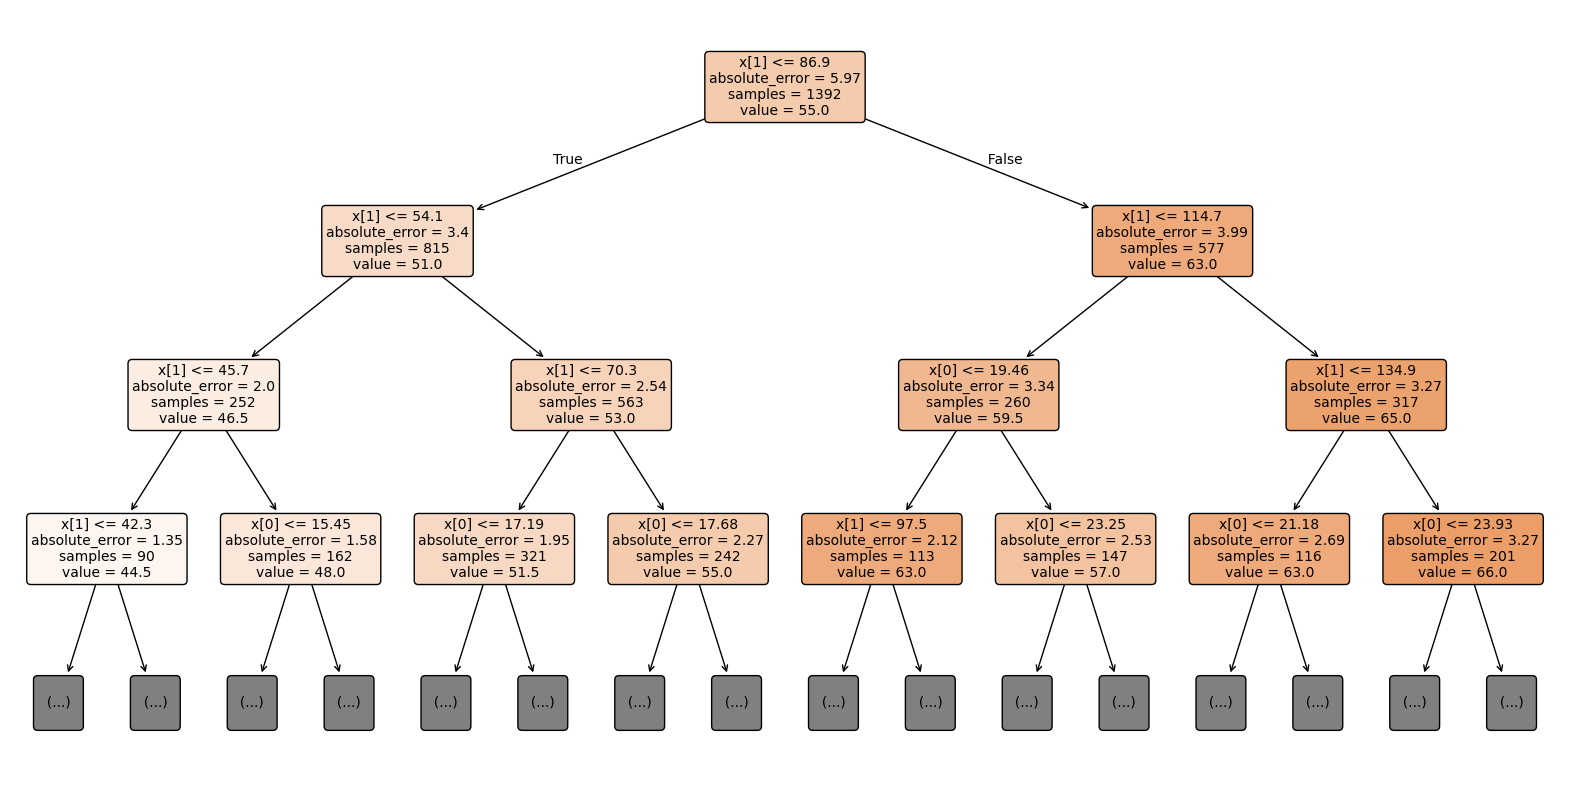

In [319]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  24 | 77.5000 |   69.2500 | 8.2500
 311 | 49.0000 |   56.5000 | 7.5000
  77 | 41.5000 |   48.0000 | 6.5000
 372 | 74.5000 |   69.2500 | 5.2500
 130 | 74.5000 |   69.2500 | 5.2500
 463 | 70.5000 |   66.5500 | 3.9500
 210 | 50.0000 |   53.0000 | 3.0000
  99 | 64.0000 |   61.0000 | 3.0000
 158 | 53.0000 |   55.6250 | 2.6250
 189 | 63.5000 |   61.0000 | 2.5000


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


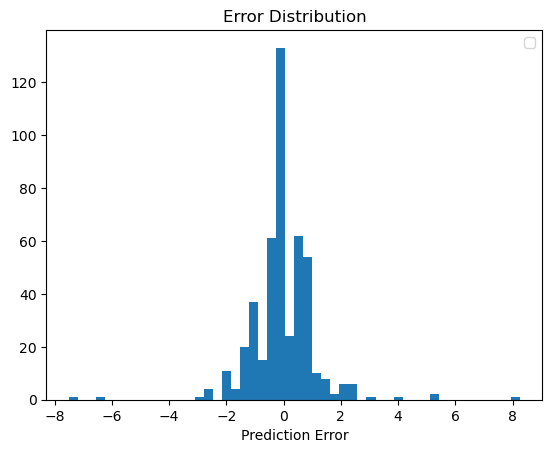

In [320]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [321]:
zipped = zip(attributes, dt_reg_height.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Weight 0.7678110996745787
Physical-BMI 0.2321889003254212


## TARGET VARIABLE BIA-BIA_TBW

In [322]:
df_BIA_TBW = dfid[['id','BIA-BIA_ECW', 'BIA-BIA_ICW','BIA-BIA_TBW','Physical-Weight']].copy()


In [323]:
df_BIA_TBW[(df_BIA_TBW['BIA-BIA_TBW']==0) |(df_BIA_TBW['BIA-BIA_TBW'].isna()) | (df_BIA_TBW['BIA-BIA_TBW']==44.987)| (df_BIA_TBW['BIA-BIA_TBW']>=df_BIA_TBW['Physical-Weight'])]

,id,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW,Physical-Weight
1162,2492,15.9280,28.8558,44.987,68.8
1275,2726,18.5764,26.4106,44.987,84.0


In [324]:
list1 = [2492, 2726]

df_BIA_TBW=df_BIA_TBW[df_BIA_TBW.id.isin(list1) == False]

In [325]:
df_BIA_TBW

,id,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW,Physical-Weight
0,1,6.01993,21.0352,27.0552,46.0
1,3,15.59250,30.4041,45.9966,81.6
2,5,30.21240,32.9141,63.1265,112.2
3,6,16.32750,30.8936,47.2211,84.6
4,7,21.94000,28.5367,50.4767,84.2
...,...,...,...,...,...
1852,3952,39.01240,52.4763,91.4887,186.4
1853,3953,11.00630,25.7118,36.7181,67.2
1854,3954,9.98802,20.0572,30.0453,46.6
1855,3955,19.46110,33.3709,52.8320,82.4


In [326]:
df_BIA_TBW=df_BIA_TBW.drop(columns = ['id','Physical-Weight'])

In [327]:
df_BIA_TBW

,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW
0,6.01993,21.0352,27.0552
1,15.59250,30.4041,45.9966
2,30.21240,32.9141,63.1265
3,16.32750,30.8936,47.2211
4,21.94000,28.5367,50.4767
...,...,...,...
1852,39.01240,52.4763,91.4887
1853,11.00630,25.7118,36.7181
1854,9.98802,20.0572,30.0453
1855,19.46110,33.3709,52.8320


In [328]:
df_BIA_TBW.isnull().sum()

BIA-BIA_ECW    0
BIA-BIA_ICW    0
BIA-BIA_TBW    0
dtype: int64

In [329]:
df_BIA_TBW[df_BIA_TBW['BIA-BIA_TBW']==0]

,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW


### Partitioning

In [330]:
attributes = [col for col in df_BIA_TBW.columns if col != 'BIA-BIA_TBW']
X = df_BIA_TBW[attributes].values
y = np.array(df_BIA_TBW['BIA-BIA_TBW'])

In [331]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [332]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1391, 2) (464, 2) (1391,) (464,)


In [333]:
df_BIA_TBW.shape

(1855, 3)

### Randomized Search

In [334]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [335]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_TBW = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_TBW = random_search.best_estimator_

In [336]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 26, 'criterion': 'absolute_error'} -2.0287274917943257


In [337]:
dt_reg_TBW = random_search.best_estimator_
dt_reg_TBW.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=26,
                      min_samples_leaf=5, min_samples_split=0.001)

In [338]:
y_pred = dt_reg_TBW.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.1841
MAE  : 0.6325
MSE  : 1.4020
R²   : 0.9960


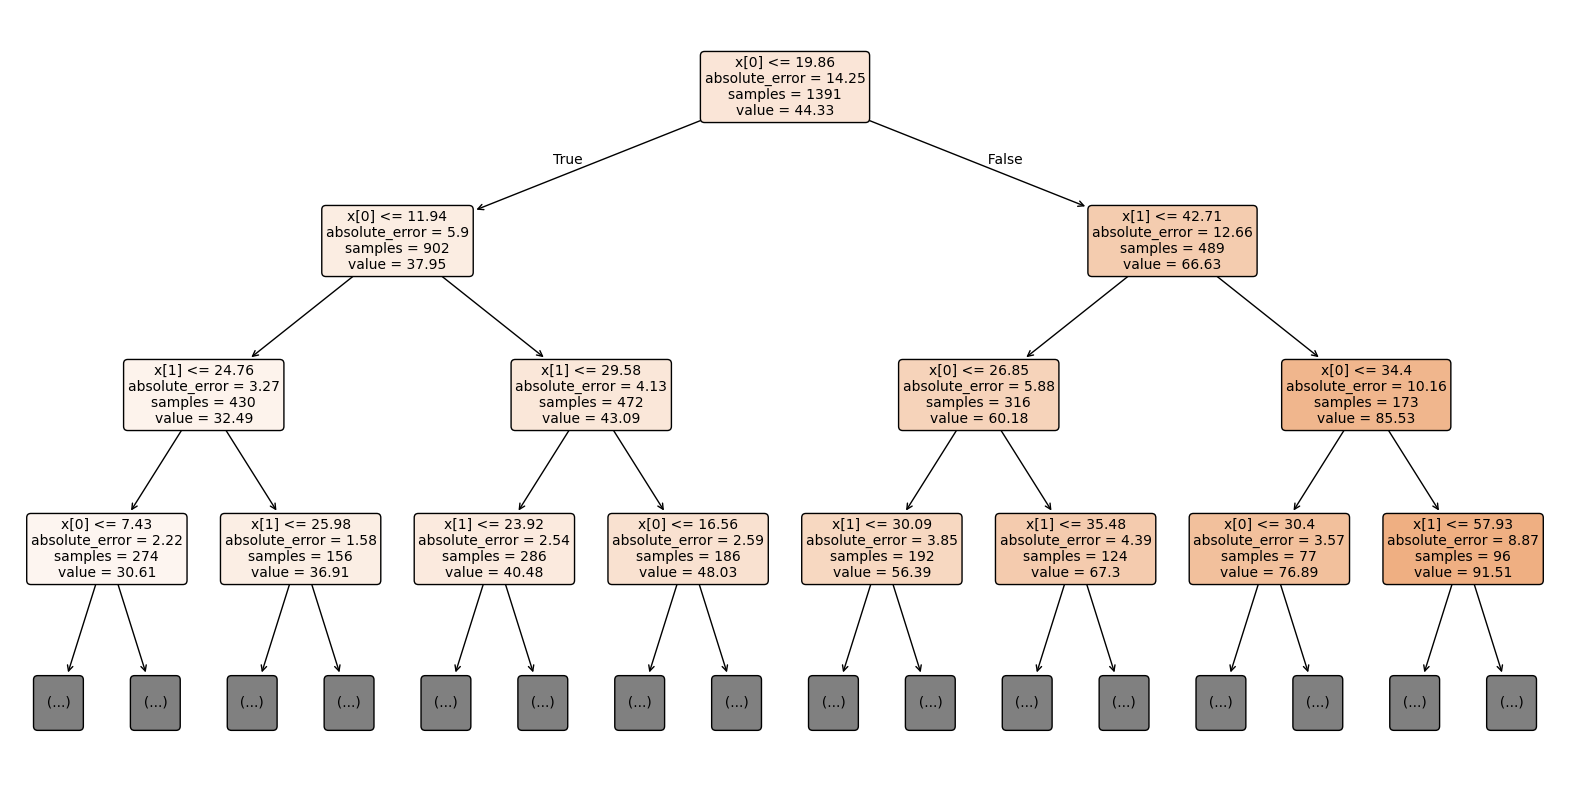

In [339]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_TBW,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 176 | 143.2380 |  132.0550 | 11.1830
 201 | 123.5600 |  132.0550 | 8.4950
  56 | 125.9560 |  118.0220 | 7.9340
 271 | 113.2760 |  108.2485 | 5.0275
 270 | 112.9330 |  108.2485 | 4.6845
 351 | 74.7493 |   79.2283 | 4.4790
 244 | 51.0086 |   46.5631 | 4.4455
  95 | 22.8800 |   26.9029 | 4.0229
 449 | 99.4712 |  103.2245 | 3.7533
 290 | 94.2103 |   97.5550 | 3.3447


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


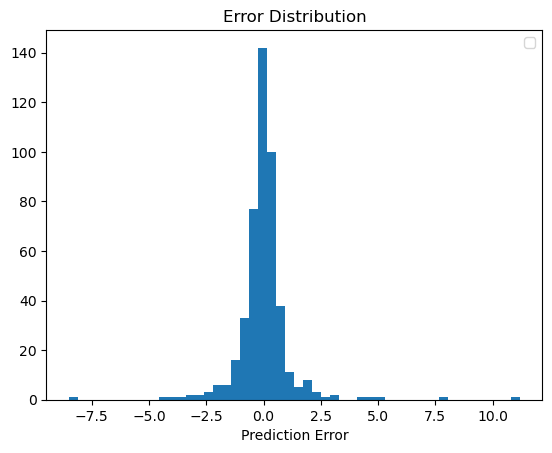

In [340]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [341]:
zipped = zip(attributes, dt_reg_TBW.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_ECW 0.6787980015424947
BIA-BIA_ICW 0.32120199845750524


## TARGET VARIABLE BIA-BIA_Fat

In [342]:
df_BIA_Fat = dfid[['id','Physical-Weight', 
                'Physical-Height','BIA-BIA_FMI',
                'BIA-BIA_Fat'                          
]].copy()



In [343]:
df_BIA_Fat[(df_BIA_Fat['BIA-BIA_Fat']<=0) |(df_BIA_Fat['BIA-BIA_Fat'].isna()) | (df_BIA_Fat['BIA-BIA_Fat']==16.1746)| (df_BIA_Fat['BIA-BIA_Fat']>=df_BIA_Fat['Physical-Weight'])]

,id,Physical-Weight,Physical-Height,BIA-BIA_FMI,BIA-BIA_Fat
498,1089,83.8,57.5,3.43954,16.1746
1162,2492,68.8,53.0,3.69863,16.1746


In [344]:
list1 = [1089, 2492]

df_BIA_Fat=df_BIA_Fat[df_BIA_Fat.id.isin(list1) == False]
df_BIA_Fat=df_BIA_Fat.drop(columns = ['id'])
df_BIA_Fat


,Physical-Weight,Physical-Height,BIA-BIA_FMI,BIA-BIA_Fat
0,46.0,48.00,1.211720,3.97085
1,81.6,56.00,4.220330,18.82430
2,112.2,59.50,13.498800,67.97150
3,84.6,55.00,4.962910,21.35300
4,84.2,59.25,3.253950,16.24740
...,...,...,...,...
1852,186.4,70.50,8.630020,61.00800
1853,67.2,52.50,3.741300,14.66690
1854,46.6,48.50,0.414263,1.41470
1855,82.4,59.50,2.301380,11.58830


In [345]:
df_BIA_Fat.isnull().sum()

Physical-Weight    0
Physical-Height    0
BIA-BIA_FMI        0
BIA-BIA_Fat        0
dtype: int64

### Partitioning

In [346]:
attributes = [col for col in df_BIA_Fat.columns if col != 'BIA-BIA_Fat']
X = df_BIA_Fat[attributes].values
y = np.array(df_BIA_Fat['BIA-BIA_Fat'])

In [347]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [348]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1391, 3) (464, 3) (1391,) (464,)


In [349]:
df_BIA_Fat.shape

(1855, 4)

### Randomized Search

In [350]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [351]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_FAT = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_FAT = random_search.best_estimator_

In [352]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 18, 'criterion': 'squared_error'} -8.061032764651834


In [353]:
dt_reg_FAT = random_search.best_estimator_
dt_reg_FAT.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=18, min_samples_leaf=5, min_samples_split=0.001)

In [354]:
y_pred = dt_reg_FAT.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 2.4843
MAE  : 1.2901
MSE  : 6.1719
R²   : 0.9855


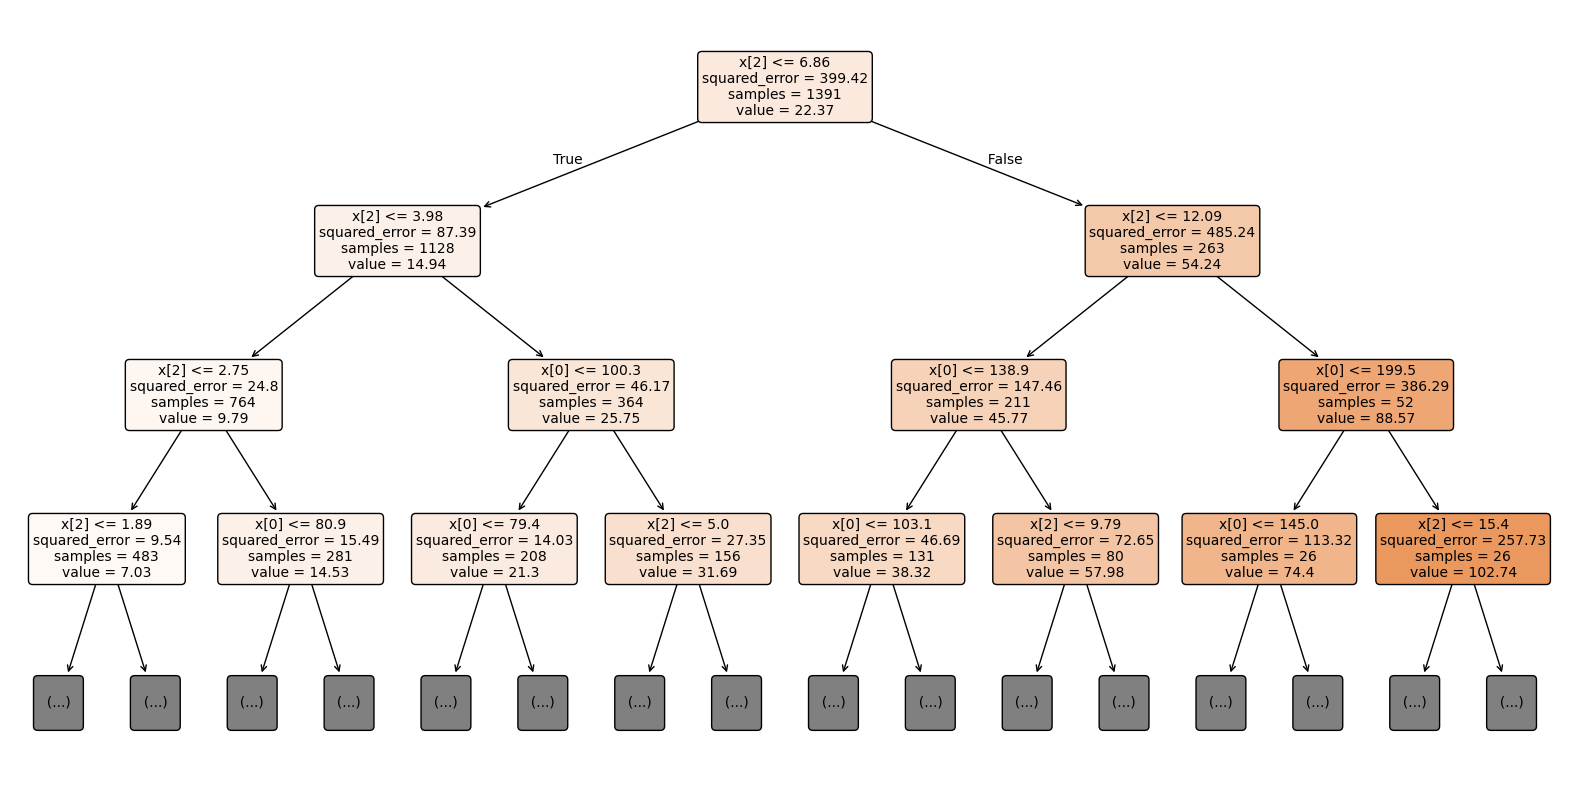

In [355]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_FAT,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 398 | 33.8424 |   59.9996 | 26.1572
 197 | 108.5070 |  125.7332 | 17.2262
 279 | 79.5701 |   63.5248 | 16.0453
 341 | 75.3255 |   63.5248 | 11.8007
 172 | 83.5875 |   73.4805 | 10.1070
  74 | 75.4429 |   84.4816 | 9.0387
 373 | 116.9160 |  125.7332 | 8.8172
 187 | 92.7019 |   84.9050 | 7.7969
 125 | 58.5514 |   52.1200 | 6.4314
 248 | 65.2936 |   71.2862 | 5.9926


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


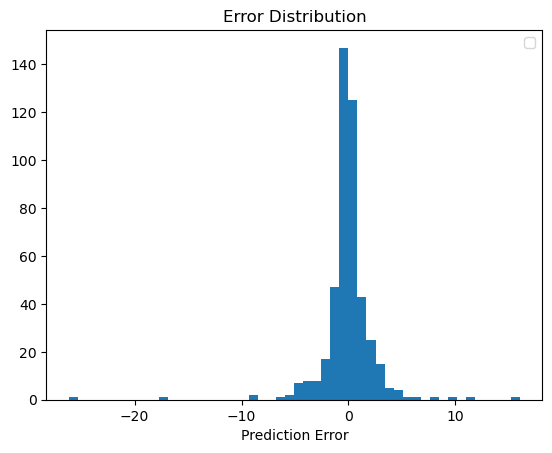

In [356]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [357]:
zipped = zip(attributes, dt_reg_FAT.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_FMI 0.8938699795346224
Physical-Weight 0.10213882774998674
Physical-Height 0.003991192715390841


## TARGET VARIABLE BIA-BIA_DEE

In [358]:
df_BIA_DEE = dfid[['id',
    'BIA-BIA_DEE',
    'BIA-BIA_BMR',                  
    'BIA-BIA_Activity_Level_num',   
    'Basic_Demos-Sex',
    'BIA-BIA_TBW'         
]]



In [359]:
df_BIA_DEE[(df_BIA_DEE['BIA-BIA_DEE']==0) |(df_BIA_DEE['BIA-BIA_DEE'].isna()) | (df_BIA_DEE['BIA-BIA_DEE']==1863.98)]

,id,BIA-BIA_DEE,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,Basic_Demos-Sex,BIA-BIA_TBW
336,736,1863.98,1164.99,2.0,0,50.8638
1162,2492,NaN,1062.40,3.0,1,44.9870


In [360]:
list1 = [736, 2492]

df_BIA_DEE=df_BIA_DEE[df_BIA_DEE.id.isin(list1) == False]
df_BIA_DEE=df_BIA_DEE.drop(columns = ['id'])
df_BIA_DEE

,BIA-BIA_DEE,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,Basic_Demos-Sex,BIA-BIA_TBW
0,1498.65,936.656,2.0,0,27.0552
1,1923.44,1131.430,3.0,0,45.9966
2,1996.45,1330.970,2.0,1,63.1265
3,1817.38,1135.860,2.0,0,47.2211
4,1888.06,1180.040,3.0,1,50.4767
...,...,...,...,...,...
1852,2922.82,1719.310,3.0,0,91.4887
1853,1759.96,1035.270,3.0,0,36.7181
1854,1256.17,966.287,1.0,1,30.0453
1855,2051.70,1206.880,3.0,0,52.8320


In [361]:
df_BIA_DEE.isnull().sum()

BIA-BIA_DEE                   0
BIA-BIA_BMR                   0
BIA-BIA_Activity_Level_num    0
Basic_Demos-Sex               0
BIA-BIA_TBW                   0
dtype: int64

### Partitioning

In [362]:
attributes = [col for col in df_BIA_DEE.columns if col != 'BIA-BIA_DEE']
X = df_BIA_DEE[attributes].values
y = np.array(df_BIA_DEE['BIA-BIA_DEE'])

In [363]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [364]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1391, 4) (464, 4) (1391,) (464,)


In [365]:
df_BIA_DEE.shape

(1855, 5)

### Randomized Search

In [366]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [367]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_DEE = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_DEE = random_search.best_estimator_

In [368]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 38, 'criterion': 'absolute_error'} -6566.87332290013


In [369]:
dt_reg_DEE = random_search.best_estimator_
dt_reg_DEE.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=38,
                      min_samples_leaf=5, min_samples_split=0.001)

In [370]:
y_pred = dt_reg_DEE.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 89.4871
MAE  : 34.0413
MSE  : 8007.9348
R²   : 0.9704


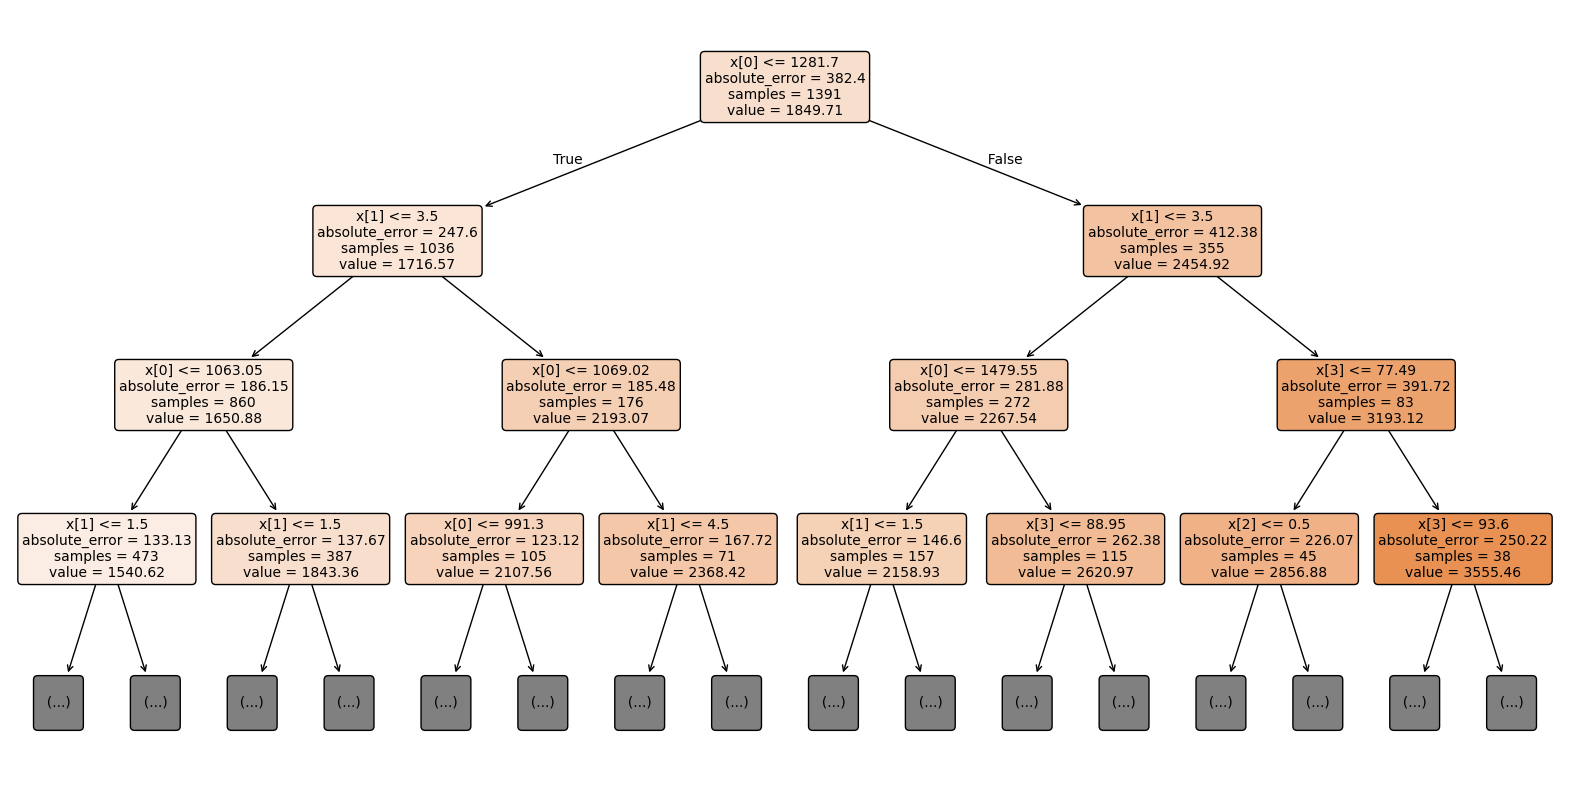

In [371]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_DEE,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  48 | 2654.6100 | 3516.9850 | 862.3750
 279 | 2818.9700 | 3516.9850 | 698.0150
 361 | 2906.3600 | 3516.9850 | 610.6250
 345 | 4517.1300 | 3915.7350 | 601.3950
 434 | 3724.5800 | 3241.3200 | 483.2600
 197 | 3071.1600 | 3516.9850 | 445.8250
 401 | 3189.5500 | 2823.8800 | 365.6700
   8 | 2990.8500 | 3335.9700 | 345.1200
 265 | 3167.9400 | 2823.8800 | 344.0600
 341 | 3409.3500 | 3136.7300 | 272.6200


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


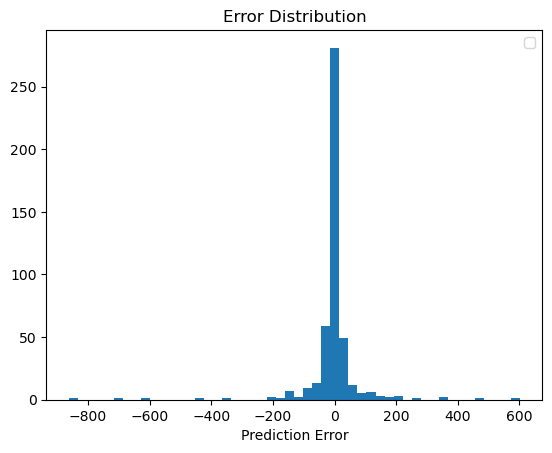

In [372]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [373]:
zipped = zip(attributes, dt_reg_DEE.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_BMR 0.5407153152833404
BIA-BIA_Activity_Level_num 0.3451020315608685
BIA-BIA_TBW 0.06981922401197288
Basic_Demos-Sex 0.04436342914381828


## TARGET VARIABLE BIA-BIA_BMC

In [374]:
df_BIA_BMC = dfid[['id',
'BIA-BIA_LST' ,
'BIA-BIA_ICW',
'BIA-BIA_BMR' ,
'BIA-BIA_BMC'
]]





In [375]:
df_BIA_BMC[(df_BIA_BMC['BIA-BIA_BMC']<=0) |(df_BIA_BMC['BIA-BIA_BMC'].isna()) | (df_BIA_BMC['BIA-BIA_BMC']==3.92272)]

,id,BIA-BIA_LST,BIA-BIA_ICW,BIA-BIA_BMR,BIA-BIA_BMC
1162,2492,56.9964,28.8558,1062.40,3.92272
1848,3945,57.3004,29.6535,1116.86,3.92272


In [376]:
list1 = [3945, 2492]

df_BIA_BMC=df_BIA_BMC[df_BIA_BMC.id.isin(list1) == False]
df_BIA_BMC=df_BIA_BMC.drop(columns = ['id'])
df_BIA_BMC

,BIA-BIA_LST,BIA-BIA_ICW,BIA-BIA_BMR,BIA-BIA_BMC
0,39.4497,21.0352,936.656,2.57949
1,58.9338,30.4041,1131.430,3.84191
2,79.6982,32.9141,1330.970,4.33036
3,59.4643,30.8936,1135.860,3.78271
4,63.8954,28.5367,1180.040,4.05726
...,...,...,...,...
1852,118.4330,52.4763,1719.310,6.95881
1853,49.3301,25.7118,1035.270,3.20303
1854,42.8185,20.0572,966.287,2.36680
1855,66.2889,33.3709,1206.880,4.52277


In [377]:
df_BIA_BMC.isnull().sum()

BIA-BIA_LST    0
BIA-BIA_ICW    0
BIA-BIA_BMR    0
BIA-BIA_BMC    0
dtype: int64

### Partitioning

In [378]:
attributes = [col for col in df_BIA_BMC.columns if col != 'BIA-BIA_BMC']
X = df_BIA_BMC[attributes].values
y = np.array(df_BIA_BMC['BIA-BIA_BMC'])

In [379]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [380]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1391, 3) (464, 3) (1391,) (464,)


In [381]:
df_BIA_BMC.shape

(1855, 4)

### Randomized Search

In [382]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [383]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_BMC = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_BMC = random_search.best_estimator_

In [384]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 22, 'criterion': 'squared_error'} -1.8416737206066276


In [385]:
dt_reg_BMC = random_search.best_estimator_
dt_reg_BMC.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=22, min_samples_leaf=5, min_samples_split=0.001)

In [386]:
y_pred = dt_reg_BMC.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.2299
MAE  : 0.6324
MSE  : 1.5127
R²   : 0.7383


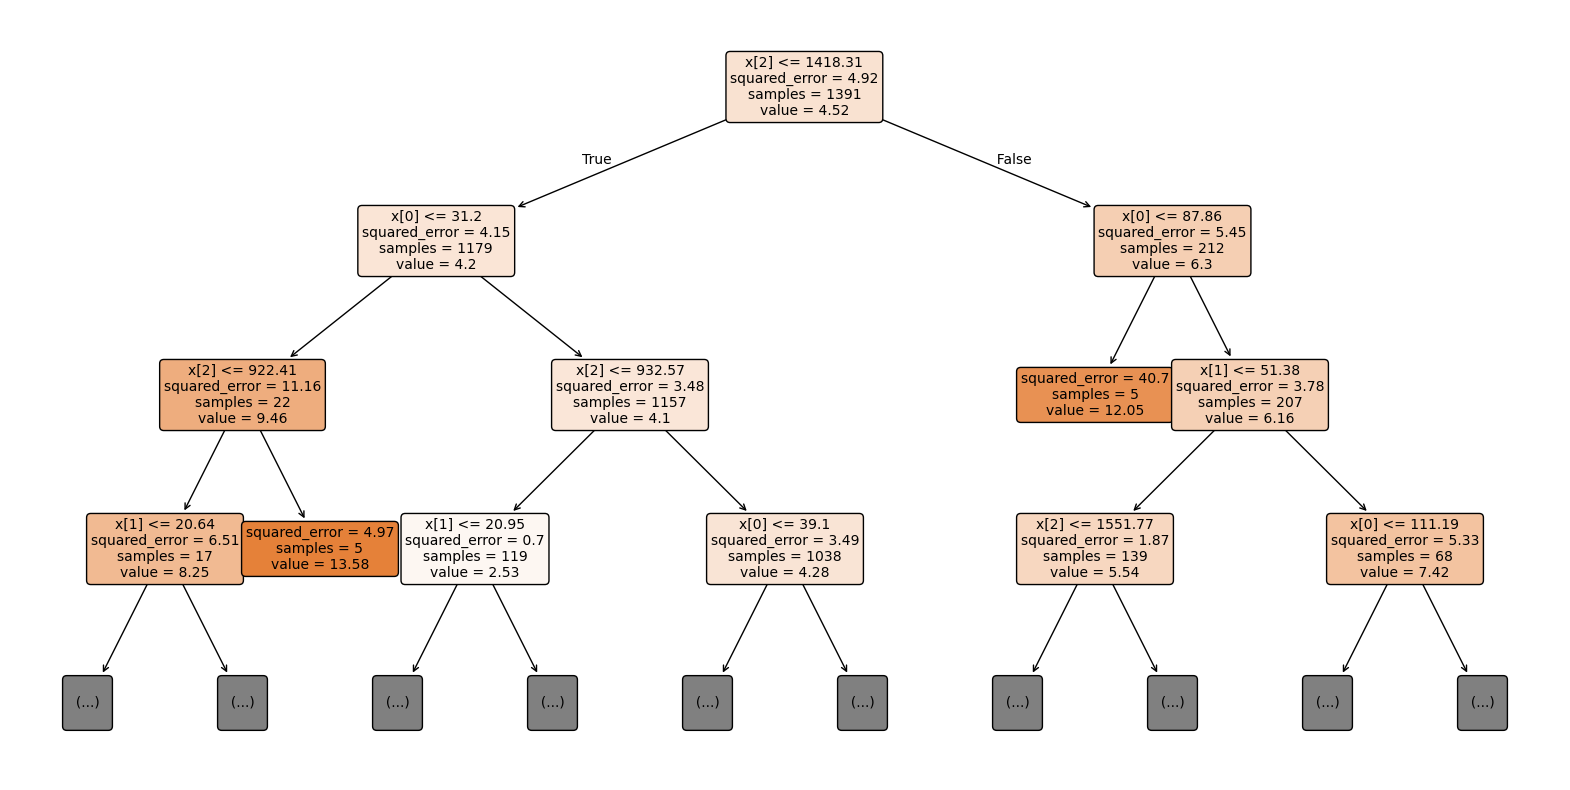

In [387]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_BMC,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 174 | 15.1353 |    5.2342 | 9.9011
  26 | 22.4353 |   13.5825 | 8.8528
 178 | 11.0942 |    4.8319 | 6.2623
  85 | 16.3969 |   10.6219 | 5.7750
  67 |  0.4167 |    5.7338 | 5.3170
  93 |  0.6163 |    5.5652 | 4.9489
 227 | 10.6158 |    6.2150 | 4.4008
  65 |  5.9782 |   10.2196 | 4.2414
 124 | 11.5591 |    7.4470 | 4.1121
 122 |  6.1366 |   10.2196 | 4.0830


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


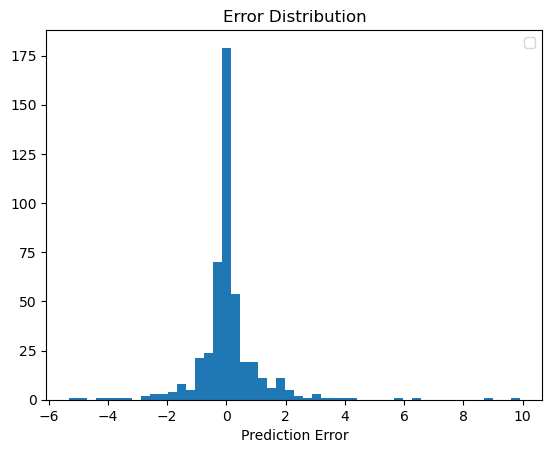

In [388]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [389]:
zipped = zip(attributes, dt_reg_BMC.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_LST 0.5169536076579483
BIA-BIA_BMR 0.40110770756232145
BIA-BIA_ICW 0.08193868477973021


## TARGET VARIABLE BIA-BIA_SMM

In [390]:
df_BIA_SMM = dfid[['id',
'BIA-BIA_LST',
'BIA-BIA_ICW',
'BIA-BIA_FFM',
'BIA-BIA_SMM',
'Physical-Weight'
]]






In [391]:
df_BIA_SMM[(df_BIA_SMM['BIA-BIA_SMM']==0) |(df_BIA_SMM['BIA-BIA_SMM'].isna()) | (df_BIA_SMM['BIA-BIA_SMM']==27.4151)| (df_BIA_SMM['BIA-BIA_SMM']>=df_BIA_SMM['BIA-BIA_FFM'])| (df_BIA_SMM['BIA-BIA_SMM']>=df_BIA_SMM['Physical-Weight'])]

,id,BIA-BIA_LST,BIA-BIA_ICW,BIA-BIA_FFM,BIA-BIA_SMM,Physical-Weight
769,1659,54.8441,26.6444,61.3799,27.4151,86.4
1162,2492,56.9964,28.8558,61.0662,27.4151,68.8


In [392]:
list1 = [1659, 2492]

df_BIA_SMM=df_BIA_SMM[df_BIA_SMM.id.isin(list1) == False]
df_BIA_SMM=df_BIA_SMM.drop(columns = ['id','Physical-Weight'])
df_BIA_SMM

,BIA-BIA_LST,BIA-BIA_ICW,BIA-BIA_FFM,BIA-BIA_SMM
0,39.4497,21.0352,42.0291,15.4107
1,58.9338,30.4041,62.7757,26.4798
2,79.6982,32.9141,84.0285,35.3804
3,59.4643,30.8936,63.2470,26.1957
4,63.8954,28.5367,67.9527,28.7680
...,...,...,...,...
1852,118.4330,52.4763,125.3920,54.2027
1853,49.3301,25.7118,52.5331,20.2645
1854,42.8185,20.0572,45.1853,18.0937
1855,66.2889,33.3709,70.8117,29.7790


In [393]:
df_BIA_SMM.isnull().sum()

BIA-BIA_LST    0
BIA-BIA_ICW    0
BIA-BIA_FFM    0
BIA-BIA_SMM    0
dtype: int64

### Partitioning

In [394]:
attributes = [col for col in df_BIA_SMM.columns if col != 'BIA-BIA_SMM']
X = df_BIA_SMM[attributes].values
y = np.array(df_BIA_SMM['BIA-BIA_SMM'])

In [395]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [396]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1391, 3) (464, 3) (1391,) (464,)


In [397]:
df_BIA_SMM.shape

(1855, 4)

### Randomized Search

In [398]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [399]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_SMM = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_SMM = random_search.best_estimator_

In [400]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.01, 'min_samples_leaf': 5, 'max_depth': 6, 'criterion': 'absolute_error'} -16.069953709957634


In [401]:
dt_reg_SMM = random_search.best_estimator_
dt_reg_SMM.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=6,
                      min_samples_leaf=5, min_samples_split=0.01)

In [402]:
y_pred = dt_reg_SMM.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 4.3309
MAE  : 2.5363
MSE  : 18.7564
R²   : 0.9087


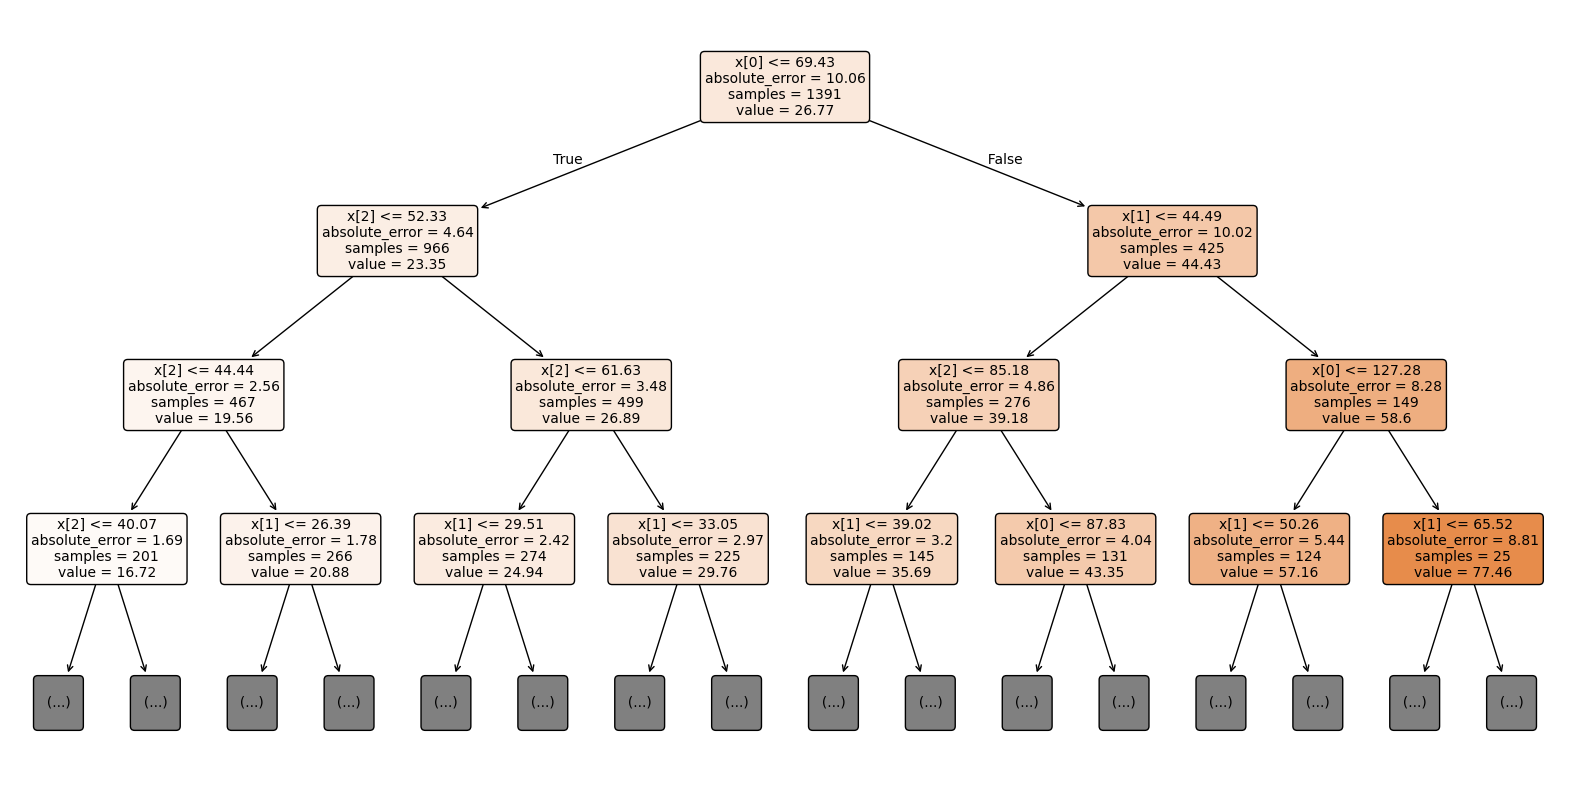

In [403]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_SMM,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 415 | 119.0850 |   83.8374 | 35.2476
 197 | 112.4690 |   83.8374 | 28.6316
 172 | 105.7740 |   83.8374 | 21.9366
 440 | 49.9916 |   33.3029 | 16.6887
 150 | 53.6596 |   37.8956 | 15.7640
 169 | 48.2171 |   33.3029 | 14.9142
  29 | 43.9279 |   29.9459 | 13.9820
 316 | 46.0271 |   33.3029 | 12.7242
 303 | 62.1284 |   49.4131 | 12.7153
   9 | 50.5667 |   37.8956 | 12.6711


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


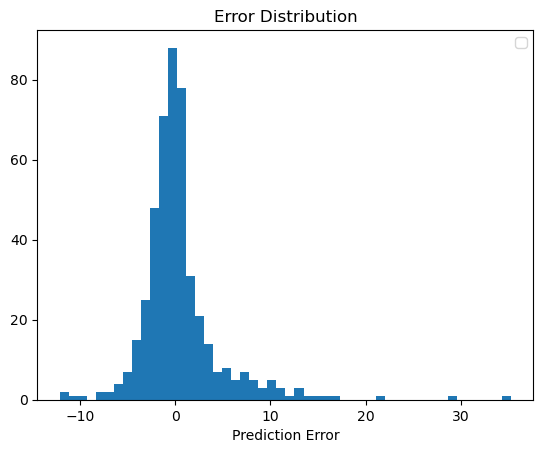

In [404]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [405]:
zipped = zip(attributes, dt_reg_SMM.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_LST 0.5191660743954634
BIA-BIA_FFM 0.2602737328875362
BIA-BIA_ICW 0.22056019271700045


## TARGET VARIABLE BIA-BIA_Activity_Level_num

In [406]:
df_BIA_ACT_LEV= df[[
'BIA-BIA_DEE',
'BIA-BIA_FFM',
'BIA-BIA_LST',
'Physical-Weight',
'BIA-BIA_ICW',
'BIA-BIA_TBW',
'BIA-BIA_Activity_Level_num'
]]

In [407]:
df_BIA_ACT_LEV=df_BIA_ACT_LEV.dropna()

In [408]:
df_BIA_ACT_LEV.isnull().sum()

BIA-BIA_DEE                   0
BIA-BIA_FFM                   0
BIA-BIA_LST                   0
Physical-Weight               0
BIA-BIA_ICW                   0
BIA-BIA_TBW                   0
BIA-BIA_Activity_Level_num    0
dtype: int64

### Partitioning

In [409]:
attributes = [col for col in df_BIA_ACT_LEV.columns if col != 'BIA-BIA_Activity_Level_num']
X = df_BIA_ACT_LEV[attributes].values
y = np.array(df_BIA_ACT_LEV['BIA-BIA_Activity_Level_num'])

In [410]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0,stratify=y)


In [411]:
print(np.unique(y, return_counts=True)[1] / len(y))
print(np.unique(y_train, return_counts=True)[1] / len(y_train))
print(np.unique(y_test, return_counts=True)[1] / len(y_test))

[0.13469828 0.32165948 0.35344828 0.1487069  0.04148707]
[0.13433908 0.32183908 0.35344828 0.1487069  0.04166667]
[0.13577586 0.32112069 0.35344828 0.1487069  0.04094828]


In [412]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 6) (464, 6) (1392,) (464,)


In [413]:
df_BIA_ACT_LEV.shape

(1856, 7)

### Randomized Search

In [414]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_CL_ACT_LEV = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_CL_ACT_LEV = random_search.best_estimator_

In [415]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 19, 'criterion': 'entropy'} 0.8606147340192362


In [416]:
dt_CL_ACT_LEV = random_search.best_estimator_
dt_CL_ACT_LEV.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=19, min_samples_leaf=5,
                       min_samples_split=0.002)

In [417]:
y_pred = dt_CL_ACT_LEV.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8771551724137931
              precision    recall  f1-score   support

         1.0       0.97      0.92      0.94        63
         2.0       0.85      0.88      0.86       149
         3.0       0.86      0.88      0.87       164
         4.0       0.92      0.86      0.89        69
         5.0       0.79      0.79      0.79        19

    accuracy                           0.88       464
   macro avg       0.88      0.86      0.87       464
weighted avg       0.88      0.88      0.88       464



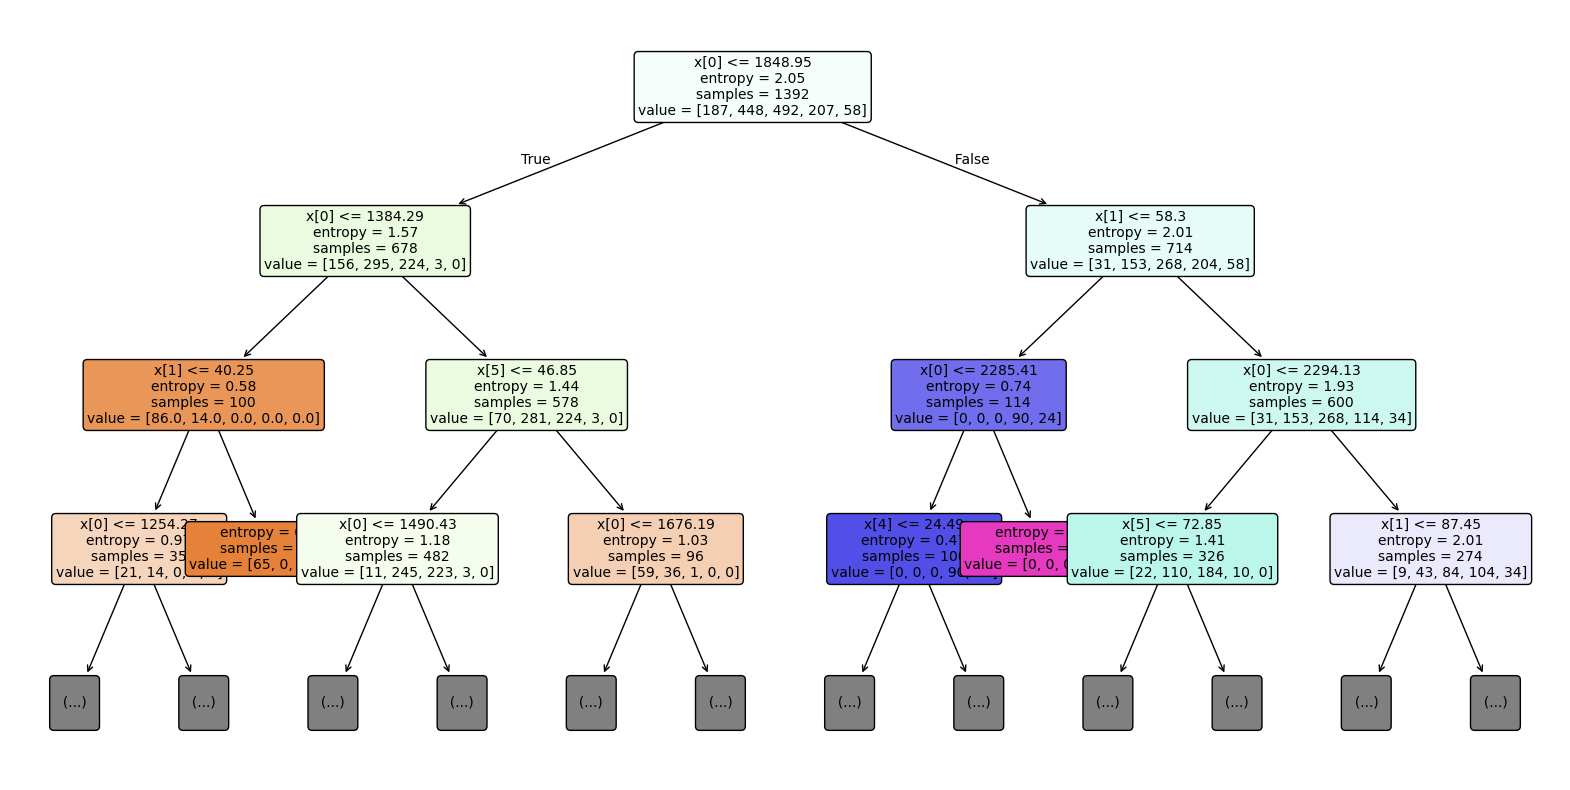

In [418]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_CL_ACT_LEV,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 439 |  5.0000 |    3.0000 | 2.0000
 463 |  3.0000 |    2.0000 | 1.0000
  78 |  3.0000 |    2.0000 | 1.0000
  72 |  1.0000 |    2.0000 | 1.0000
 380 |  2.0000 |    3.0000 | 1.0000
 381 |  2.0000 |    3.0000 | 1.0000
  56 |  1.0000 |    2.0000 | 1.0000
 260 |  3.0000 |    2.0000 | 1.0000
  51 |  3.0000 |    2.0000 | 1.0000
  50 |  4.0000 |    3.0000 | 1.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


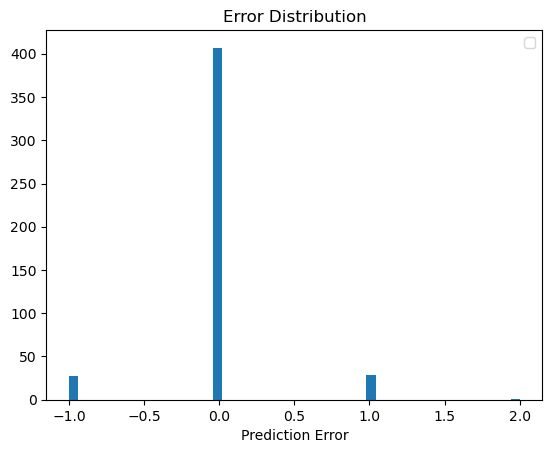

In [419]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [420]:
zipped = zip(attributes, dt_CL_ACT_LEV.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_DEE 0.4915540434058552
BIA-BIA_FFM 0.20137725280282975
BIA-BIA_TBW 0.1504244050606962
BIA-BIA_ICW 0.09897465052773696
BIA-BIA_LST 0.034987171689823966
Physical-Weight 0.02268247651305788


## TARGET VARIABLE BIA-BIA_Frame_num

In [421]:
df_BIA_Frame= df[[
       'Physical-Height', 
       'Physical-Weight',
       'BIA-BIA_Fat' ,
       'BIA-BIA_Frame_num'
]]

In [422]:
df_BIA_Frame=df_BIA_Frame.dropna()

In [423]:
df_BIA_Frame.isnull().sum()

Physical-Height      0
Physical-Weight      0
BIA-BIA_Fat          0
BIA-BIA_Frame_num    0
dtype: int64

### Partitioning

In [424]:
attributes = [col for col in df_BIA_Frame.columns if col != 'BIA-BIA_Frame_num']
X = df_BIA_Frame[attributes].values
y = np.array(df_BIA_Frame['BIA-BIA_Frame_num'])

In [425]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0,stratify=y)


In [426]:
print(np.unique(y, return_counts=True)[1] / len(y))
print(np.unique(y_train, return_counts=True)[1] / len(y_train))
print(np.unique(y_test, return_counts=True)[1] / len(y_test))

[0.39385776 0.47306034 0.1330819 ]
[0.39367816 0.47341954 0.1329023 ]
[0.39439655 0.47198276 0.13362069]


In [427]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (464, 3) (1392,) (464,)


In [428]:
df_BIA_Frame.shape

(1856, 4)

### Randomized Search

In [429]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 40)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_Frame = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_Frame = random_search.best_estimator_

In [430]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 3, 'criterion': 'entropy'} 0.6759805059178463


In [431]:
dt_reg_Frame = random_search.best_estimator_
dt_reg_Frame.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                       min_samples_split=0.002)

In [432]:
y_pred = dt_reg_Frame.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6530172413793104
              precision    recall  f1-score   support

         1.0       0.66      0.68      0.67       183
         2.0       0.63      0.72      0.67       219
         3.0       0.88      0.34      0.49        62

    accuracy                           0.65       464
   macro avg       0.72      0.58      0.61       464
weighted avg       0.67      0.65      0.65       464



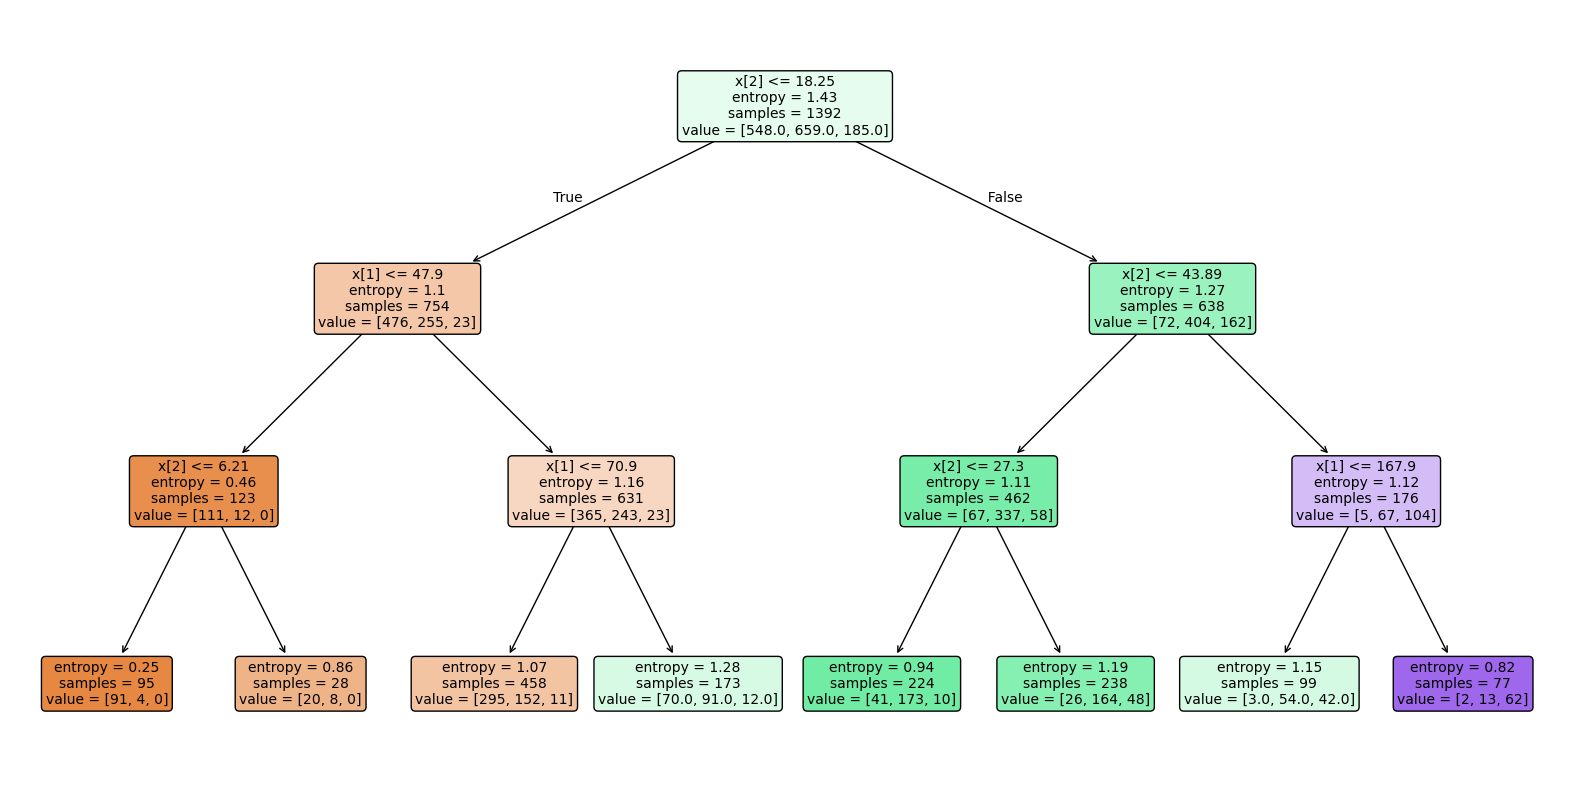

In [433]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_Frame,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 374 |  3.0000 |    1.0000 | 2.0000
 283 |  3.0000 |    1.0000 | 2.0000
 403 |  3.0000 |    1.0000 | 2.0000
 142 |  3.0000 |    1.0000 | 2.0000
  77 |  3.0000 |    1.0000 | 2.0000
   0 |  1.0000 |    2.0000 | 1.0000
  92 |  2.0000 |    1.0000 | 1.0000
 321 |  1.0000 |    2.0000 | 1.0000
 319 |  1.0000 |    2.0000 | 1.0000
 317 |  1.0000 |    2.0000 | 1.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


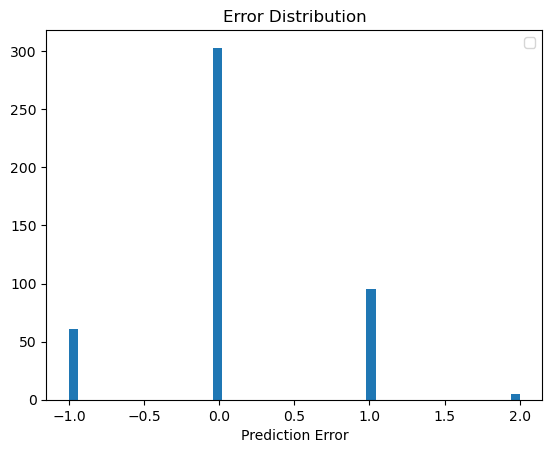

In [434]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [435]:
zipped = zip(attributes, dt_reg_Frame.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_Fat 0.8497176180587473
Physical-Weight 0.1502823819412526
Physical-Height 0.0


## ** TARGET VARIABLE Physical-HeartRate

In [436]:
df_HeartRate = df[[
       'Physical-HeartRate', 
       'Physical-Height',
       'Physical-Weight',
       'Physical-MAP_CAL'
       ]].copy()


In [437]:
df_HeartRate=df_HeartRate.dropna()

In [438]:
df_HeartRate.isnull().sum()

Physical-HeartRate    0
Physical-Height       0
Physical-Weight       0
Physical-MAP_CAL      0
dtype: int64

### Partitioning

In [439]:
attributes = [col for col in df_HeartRate.columns if col != 'Physical-HeartRate']
X = df_HeartRate[attributes].values
y = np.array(df_HeartRate['Physical-HeartRate'])

In [440]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [441]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1389, 3) (464, 3) (1389,) (464,)


In [442]:
df_HeartRate.shape

(1853, 4)

### Randomized Search

In [443]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [444]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_HeartRate = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_HeartRate = random_search.best_estimator_

In [445]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# rf_reg_HeartRate = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_HeartRate = random_search.best_estimator_

In [446]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.2, 'min_samples_leaf': 50, 'max_depth': 49, 'criterion': 'absolute_error'} -159.28568228449734


In [447]:
dt_reg_HeartRate = random_search.best_estimator_
dt_reg_HeartRate.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=49,
                      min_samples_leaf=50, min_samples_split=0.2)

In [448]:
y_pred = dt_reg_HeartRate.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 12.9506
MAE  : 10.6519
MSE  : 167.7193
R²   : -0.0140


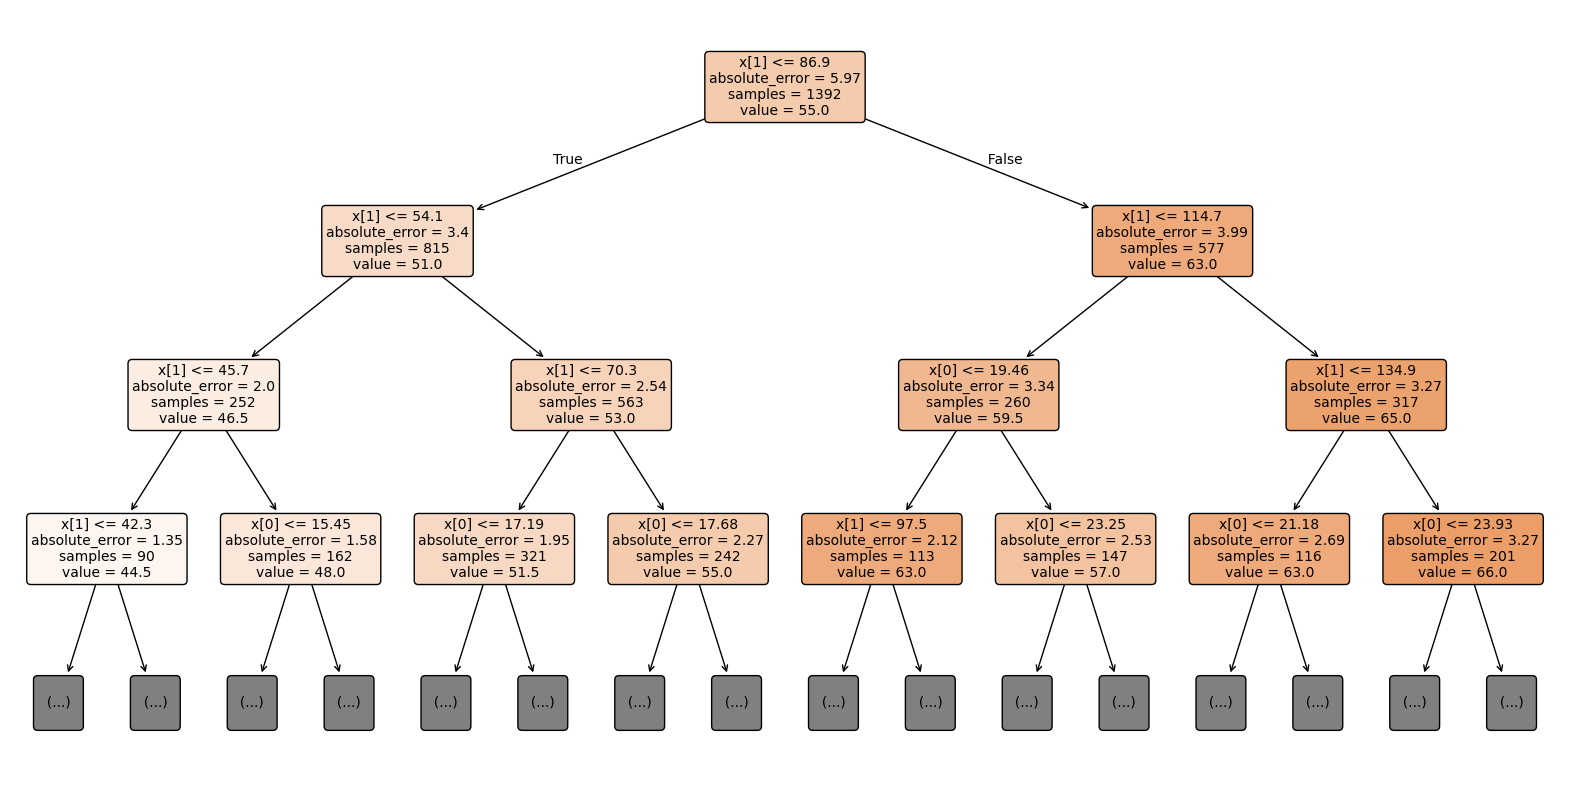

In [449]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 358 | 46.0000 |   91.0000 | 45.0000
 443 | 118.0000 |   78.0000 | 40.0000
 296 | 113.0000 |   78.0000 | 35.0000
  72 | 107.0000 |   73.0000 | 34.0000
 109 | 112.0000 |   78.0000 | 34.0000
 151 | 120.0000 |   87.5000 | 32.5000
 424 | 111.0000 |   82.0000 | 29.0000
 240 | 62.0000 |   91.0000 | 29.0000
 219 | 116.0000 |   87.5000 | 28.5000
 348 | 63.0000 |   91.0000 | 28.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


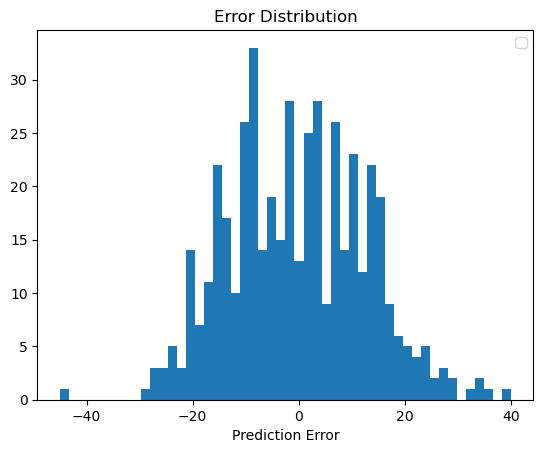

In [450]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [451]:
zipped = zip(attributes, dt_reg_HeartRate.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Height 0.5092667203867849
Physical-MAP_CAL 0.4907332796132152
Physical-Weight 0.0


## ** TARGET VARIABLE CGAS-CGAS_Score'

In [452]:
df_CGAS_Score = df[[
'CGAS-CGAS_Score', 
'SDS-SDS_Total_T',
'Physical-BMI',
'FGC-FGC_CORE_CAL',
'Physical-Weight'      
       ]].copy()



In [453]:
df_CGAS_Score=df_CGAS_Score.dropna()

In [454]:
df_CGAS_Score.isnull().sum()

CGAS-CGAS_Score     0
SDS-SDS_Total_T     0
Physical-BMI        0
FGC-FGC_CORE_CAL    0
Physical-Weight     0
dtype: int64

### Partitioning

In [455]:
attributes = [col for col in df_CGAS_Score.columns if col != 'CGAS-CGAS_Score']
X = df_CGAS_Score[attributes].values
y = np.array(df_CGAS_Score['CGAS-CGAS_Score'])

In [456]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [457]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1114, 4) (372, 4) (1114,) (372,)


In [458]:
df_CGAS_Score.shape

(1486, 5)

### Randomized Search

In [459]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [460]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_CGAS_Score = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_CGAS_Score = random_search.best_estimator_

In [461]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_CGAS_Score = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_CGAS_Score = random_search.best_estimator_

In [462]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 100, 'max_depth': 3, 'criterion': 'squared_error'} -122.63788619260727


In [463]:
dt_reg_CGAS_Score = random_search.best_estimator_
dt_reg_CGAS_Score.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=100,
                      min_samples_split=0.002)

In [464]:
y_pred = dt_reg_CGAS_Score.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 11.1533
MAE  : 9.0567
MSE  : 124.3963
R²   : 0.0038


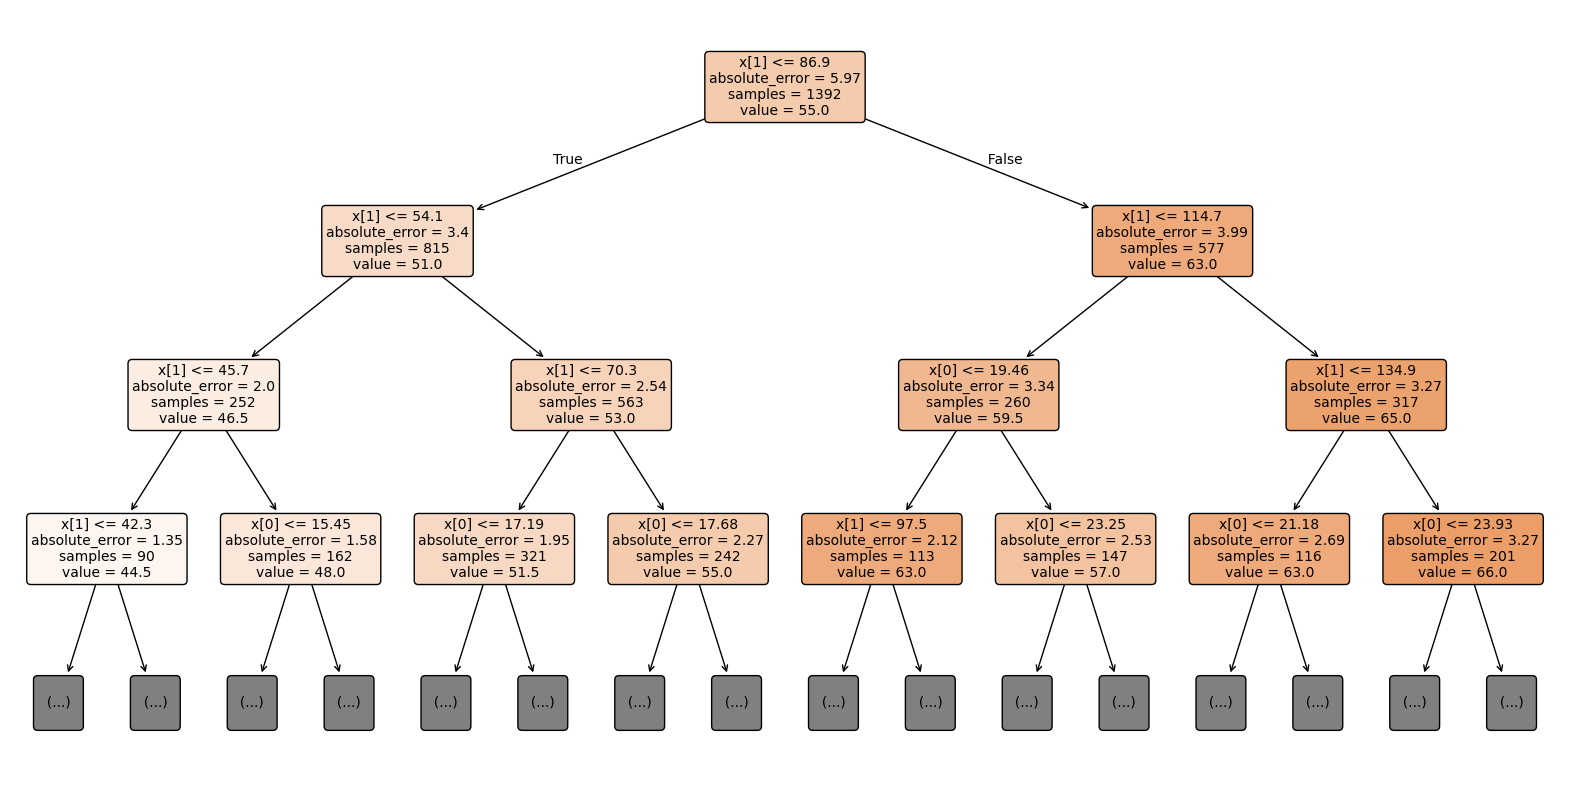

In [465]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  98 | 39.0000 |   69.9022 | 30.9022
 345 | 40.0000 |   67.8304 | 27.8304
 162 | 41.0000 |   67.2373 | 26.2373
 117 | 41.0000 |   67.2373 | 26.2373
 301 | 90.0000 |   64.0580 | 25.9420
 125 | 45.0000 |   69.9022 | 24.9022
 250 | 92.0000 |   67.8304 | 24.1696
 220 | 91.0000 |   67.8304 | 23.1696
 160 | 45.0000 |   67.8304 | 22.8304
 154 | 45.0000 |   67.8304 | 22.8304


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


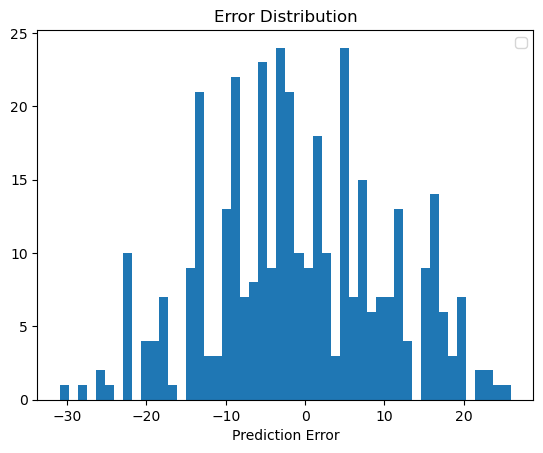

In [466]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [467]:
zipped = zip(attributes, dt_reg_CGAS_Score.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

SDS-SDS_Total_T 0.390062618848251
FGC-FGC_CORE_CAL 0.37908151418651403
Physical-Weight 0.16720230421270094
Physical-BMI 0.06365356275253412


## ** TARGET VARIABLE Fitness_Endurance-Max_Stage

In [468]:
df_Fitness_Endurance= df[[
'Physical-Weight',
'FGC-FGC_CORE_CAL',
'Basic_Demos-Age',
'Basic_Demos-Sex', 
'Physical-Height',
'BIA-BIA_FMI',
'Physical-MAP_CAL',
'BIA-BIA_TBW',
'Fitness_Endurance-Max_Stage'
]]



In [469]:
df_Fitness_Endurance=df_Fitness_Endurance.dropna()

In [470]:
df_Fitness_Endurance.isnull().sum()

Physical-Weight                0
FGC-FGC_CORE_CAL               0
Basic_Demos-Age                0
Basic_Demos-Sex                0
Physical-Height                0
BIA-BIA_FMI                    0
Physical-MAP_CAL               0
BIA-BIA_TBW                    0
Fitness_Endurance-Max_Stage    0
dtype: int64

### Partitioning

In [471]:
attributes = [col for col in df_Fitness_Endurance.columns if col != 'Fitness_Endurance-Max_Stage']
X = df_Fitness_Endurance[attributes].values
y = np.array(df_Fitness_Endurance['Fitness_Endurance-Max_Stage'])

In [472]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [473]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(904, 8) (302, 8) (904,) (302,)


In [474]:
df_Fitness_Endurance.shape

(1206, 9)

### Randomized Search

In [475]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_reg_Fitness_Endurance = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0),
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_Fitness_Endurance = random_search.best_estimator_

In [476]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_Fitness_Endurance = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_Fitness_Endurance = random_search.best_estimator_

In [477]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 20)),
#     'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['gini', 'entropy']
# }

# dt_reg_Fitness_Endurance = RandomForestClassifier(random_state=0)

# random_search = RandomizedSearchCV(
#     estimator=RandomForestClassifier(random_state=0), # Added random_state for reproducibility
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0),
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Good practice for RandomizedSearchCV
# )

# random_search.fit(X_train, y_train)
# dt_reg_Fitness_Endurance = random_search.best_estimator_

In [478]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 30, 'max_depth': 3, 'criterion': 'gini'} 0.6814487415592388


In [479]:
dt_reg_Fitness_Endurance = random_search.best_estimator_
dt_reg_Fitness_Endurance.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=30,
                       min_samples_split=0.002)

In [480]:
y_pred = dt_reg_Fitness_Endurance.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6490066225165563
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         4
         2.0       0.00      0.00      0.00        10
         3.0       0.00      0.00      0.00        16
         4.0       0.00      0.00      0.00        21
         5.0       0.65      1.00      0.79       196
         6.0       0.00      0.00      0.00        32
         7.0       0.00      0.00      0.00        20
         8.0       0.00      0.00      0.00         1
        11.0       0.00      0.00      0.00         1
        12.0       0.00      0.00      0.00         1

    accuracy                           0.65       302
   macro avg       0.06      0.10      0.08       302
weighted avg       0.42      0.65      0.51       302



c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\paula\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [481]:
y_pred = dt_reg_Fitness_Endurance.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.2139
MAE  : 0.6192
MSE  : 1.4735
R²   : -0.0009


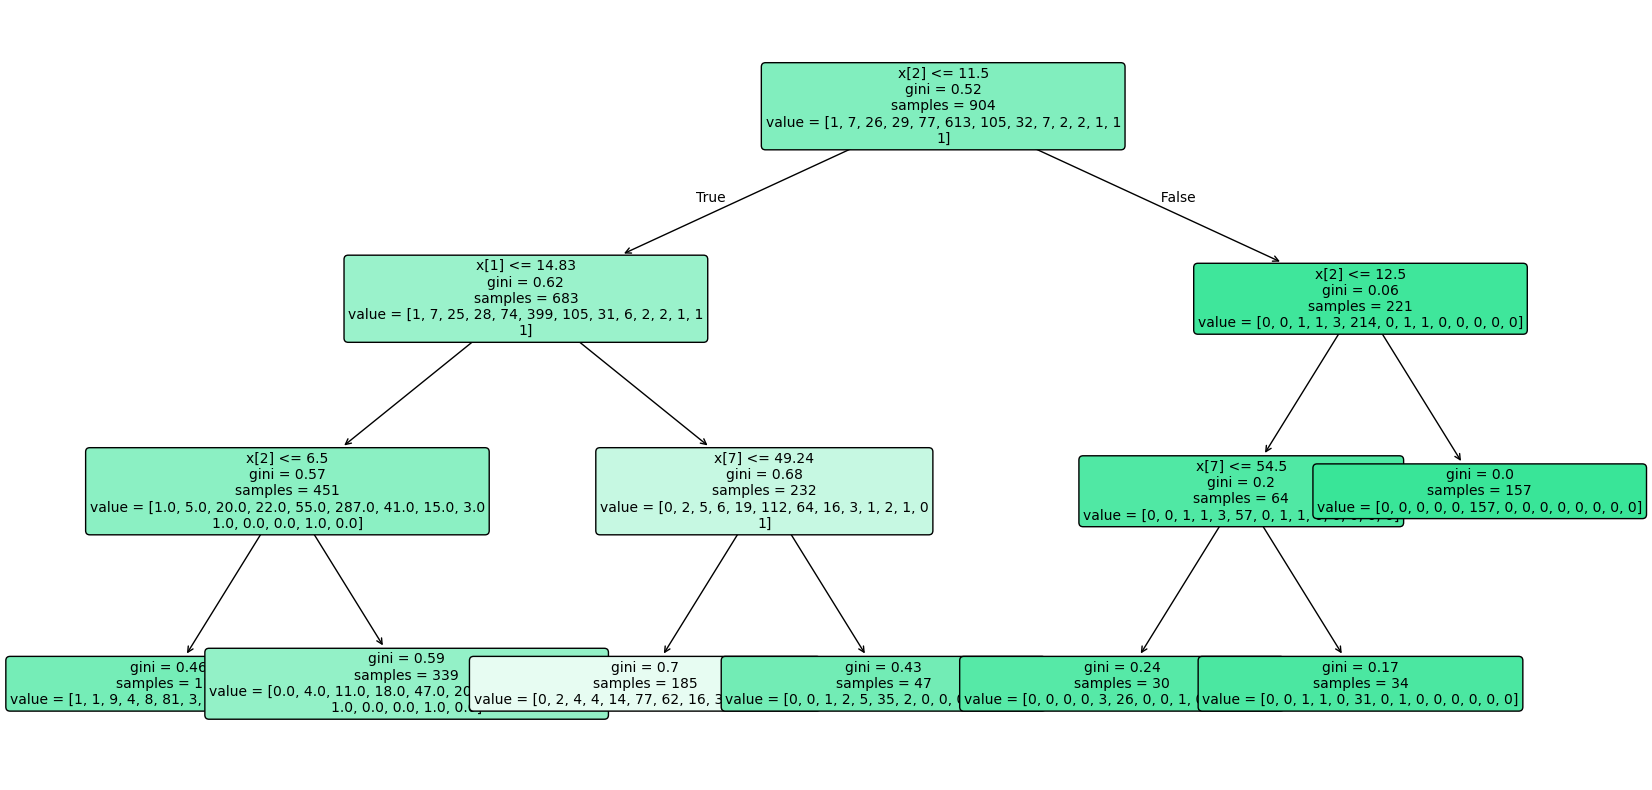

In [482]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_Fitness_Endurance,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  38 | 12.0000 |    5.0000 | 7.0000
 154 | 11.0000 |    5.0000 | 6.0000
 253 |  1.0000 |    5.0000 | 4.0000
   2 |  1.0000 |    5.0000 | 4.0000
 218 |  1.0000 |    5.0000 | 4.0000
  96 |  1.0000 |    5.0000 | 4.0000
 158 |  2.0000 |    5.0000 | 3.0000
  21 |  2.0000 |    5.0000 | 3.0000
  35 |  2.0000 |    5.0000 | 3.0000
 205 |  2.0000 |    5.0000 | 3.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


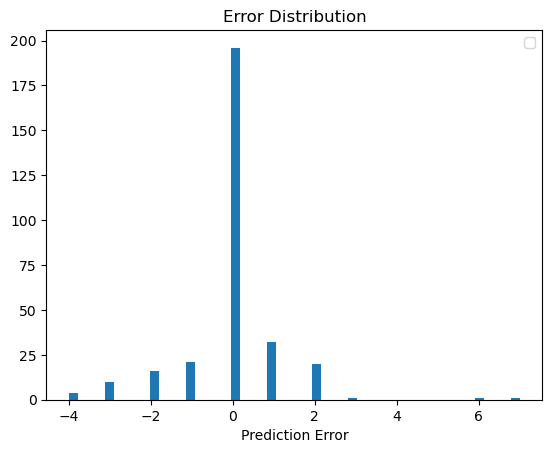

In [483]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [484]:
zipped = zip(attributes, dt_reg_Fitness_Endurance.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.6609436504773282
FGC-FGC_CORE_CAL 0.18519923939501007
BIA-BIA_TBW 0.1538571101276618
Physical-Weight 0.0
Basic_Demos-Sex 0.0
Physical-Height 0.0
BIA-BIA_FMI 0.0
Physical-MAP_CAL 0.0


## ** TARGET VARIABLE FGC-FGC_TL

In [485]:
df_FGC_TL= df[[
'FGC-FGC_TL',
'FGC-FGC_CORE_CAL',
'FGC-FGC_SR_CAL',
'BIA-BIA_ECW',
'Basic_Demos-Age',
'Basic_Demos-Sex',
'Physical-Weight',
'Physical-Height',
'BIA-BIA_TBW'
]]





In [486]:
df_FGC_TL=df_FGC_TL.dropna()

In [487]:
df_FGC_TL.isnull().sum()

FGC-FGC_TL          0
FGC-FGC_CORE_CAL    0
FGC-FGC_SR_CAL      0
BIA-BIA_ECW         0
Basic_Demos-Age     0
Basic_Demos-Sex     0
Physical-Weight     0
Physical-Height     0
BIA-BIA_TBW         0
dtype: int64

### Partitioning

In [488]:
attributes = [col for col in df_FGC_TL.columns if col != 'FGC-FGC_TL']
X = df_FGC_TL[attributes].values
y = np.array(df_FGC_TL['FGC-FGC_TL'])

In [489]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [490]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1281, 8) (427, 8) (1281,) (427,)


In [491]:
df_FGC_TL.shape

(1708, 9)

### Randomized Search

In [492]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [493]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_FGC_TL = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=10, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_FGC_TL = random_search.best_estimator_

In [494]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_FGC_TL = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_FGC_TL = random_search.best_estimator_

In [495]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.05, 'min_samples_leaf': 100, 'max_depth': 12, 'criterion': 'friedman_mse'} -6.6904047565639315


In [496]:
dt_reg_FGC_TL = random_search.best_estimator_
dt_reg_FGC_TL.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=12,
                      min_samples_leaf=100, min_samples_split=0.05)

In [497]:
y_pred = dt_reg_FGC_TL.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 2.6549
MAE  : 2.1249
MSE  : 7.0487
R²   : 0.1338


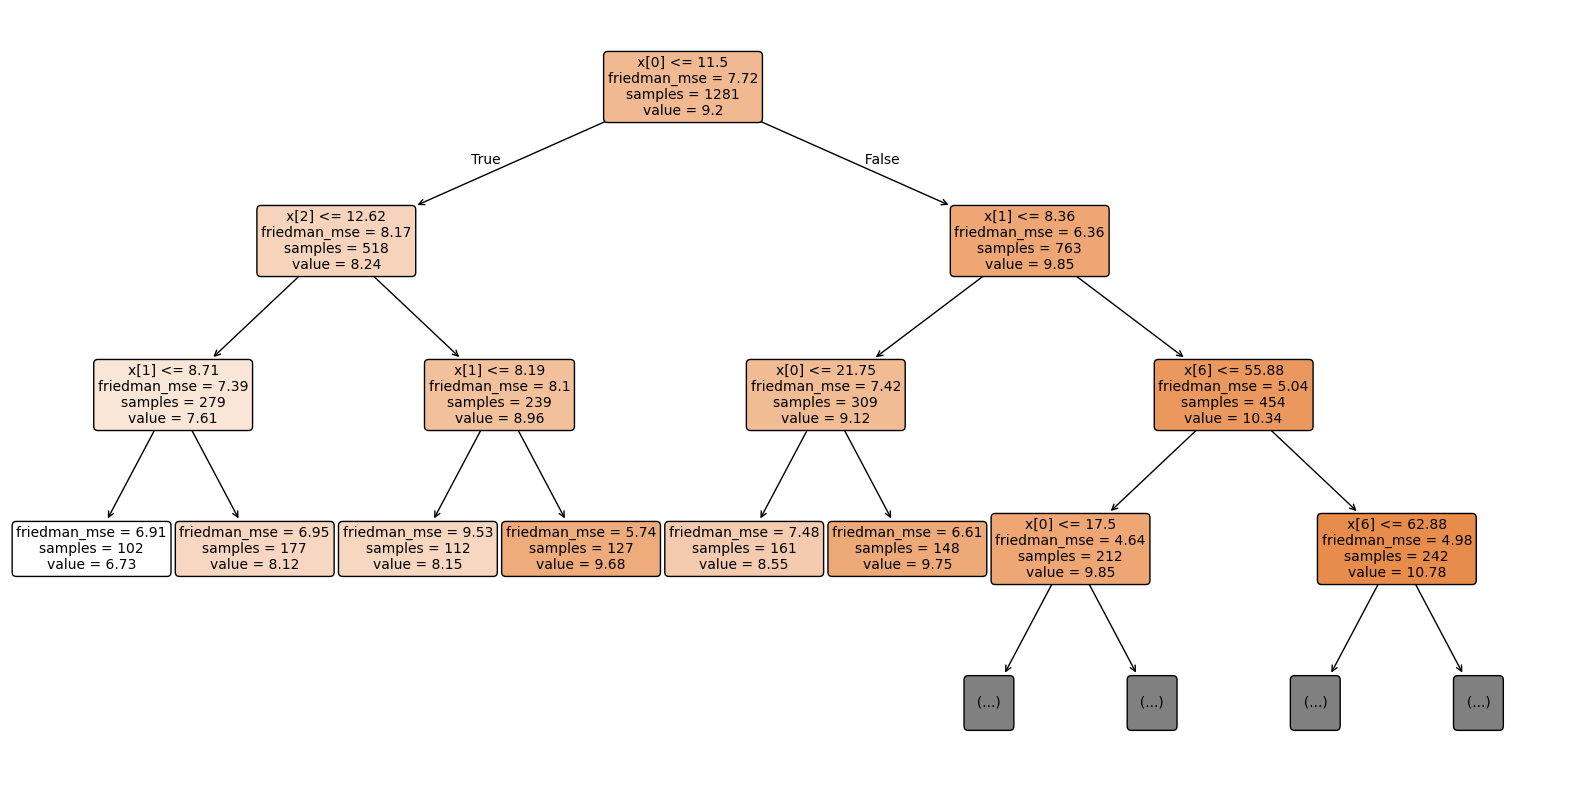

In [498]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_FGC_TL,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  43 |  0.0000 |    9.7466 | 9.7466
  38 | 19.0000 |    9.7466 | 9.2534
 296 |  0.0000 |    8.1243 | 8.1243
 242 |  3.0000 |   10.0683 | 7.0683
 384 |  0.0000 |    6.7255 | 6.7255
   4 | 17.0000 |   10.4415 | 6.5585
  11 |  5.0000 |   11.1652 | 6.1652
 115 |  2.0000 |    8.1518 | 6.1518
  47 |  4.0000 |    9.7466 | 5.7466
 332 |  4.0000 |    9.6772 | 5.6772


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


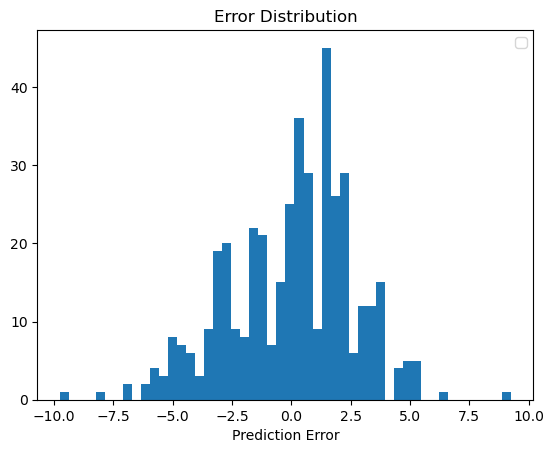

In [499]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [500]:
zipped = zip(attributes, dt_reg_FGC_TL.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

FGC-FGC_CORE_CAL 0.5060297663622234
FGC-FGC_SR_CAL 0.2951184282217603
BIA-BIA_ECW 0.12840805707977362
Physical-Height 0.07044374833624266
Basic_Demos-Age 0.0
Basic_Demos-Sex 0.0
Physical-Weight 0.0
BIA-BIA_TBW 0.0


## ** TARGET VARIABLE SDS-SDS_Total_T

In [501]:
df_SDS_Total= df[[
'SDS-SDS_Total_T',
'Basic_Demos-Age','Basic_Demos-Sex', 'Physical-Weight',
'Physical-Height','BIA-BIA_FMI','BIA-BIA_FFMI',
]]




In [502]:
df_SDS_Total=df_SDS_Total.dropna()

In [503]:
df_SDS_Total.isnull().sum()

SDS-SDS_Total_T    0
Basic_Demos-Age    0
Basic_Demos-Sex    0
Physical-Weight    0
Physical-Height    0
BIA-BIA_FMI        0
BIA-BIA_FFMI       0
dtype: int64

### Partitioning

In [504]:
attributes = [col for col in df_SDS_Total.columns if col != 'SDS-SDS_Total_T']
X = df_SDS_Total[attributes].values
y = np.array(df_SDS_Total['SDS-SDS_Total_T'])

In [505]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [506]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1194, 6) (399, 6) (1194,) (399,)


In [507]:
df_SDS_Total.shape

(1593, 7)

### Randomized Search

In [508]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [509]:
param_list = {
    'max_depth': [None] + list(np.arange(10, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_SDS_Total = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_SDS_Total = random_search.best_estimator_

In [510]:
# param_list = {
#     'n_estimators': [50, 100, 200, 300, 500],
#     'max_depth': [None] + list(np.arange(2, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse'],
#     'max_features': ['sqrt', 'log2', None] # Optional: highly recommended to tune for RFs
# }

# dt_reg_SDS_Total = RandomForestRegressor(random_state=0)


# random_search = RandomizedSearchCV(
#     estimator=RandomForestRegressor(random_state=0),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error',   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
#     random_state=0 # Ensures the random search picks the same combinations on reruns
# )

# random_search.fit(X_train, y_train)
# dt_reg_SDS_Total = random_search.best_estimator_

In [511]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 150, 'max_depth': 27, 'criterion': 'friedman_mse'} -178.70670499660747


In [512]:
dt_reg_SDS_Total = random_search.best_estimator_
dt_reg_SDS_Total.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=27,
                      min_samples_leaf=150, min_samples_split=0.002)

In [513]:
y_pred = dt_reg_SDS_Total.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 13.0766
MAE  : 10.1735
MSE  : 170.9967
R²   : -0.0225


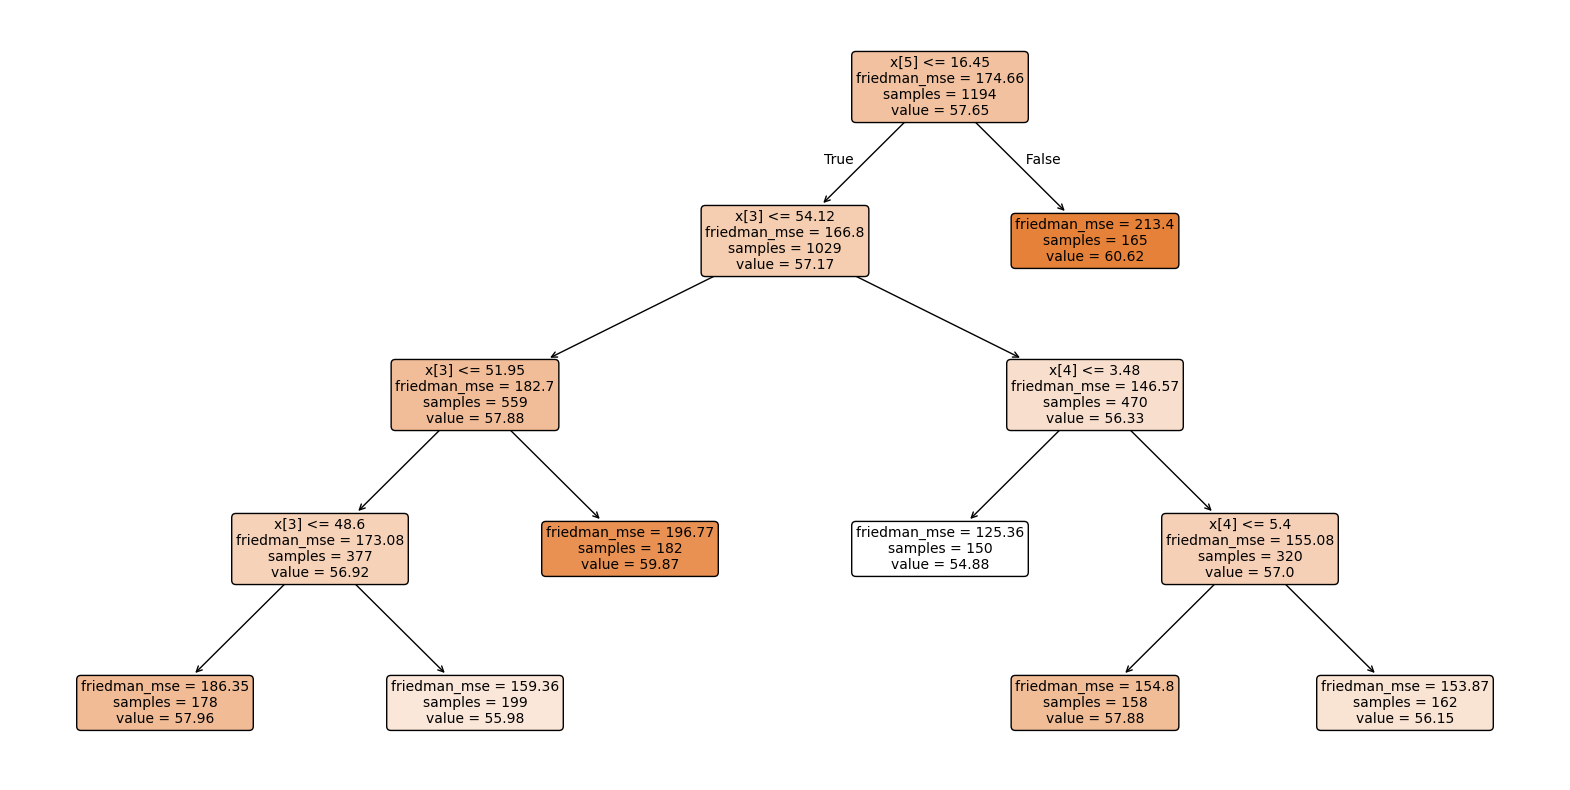

In [514]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_SDS_Total,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 4
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 204 | 100.0000 |   54.8800 | 45.1200
 306 | 100.0000 |   55.9849 | 44.0151
  40 | 100.0000 |   55.9849 | 44.0151
 357 | 100.0000 |   57.8797 | 42.1203
 245 | 100.0000 |   57.9607 | 42.0393
 340 | 99.0000 |   59.8681 | 39.1319
 127 | 94.0000 |   54.8800 | 39.1200
 339 | 95.0000 |   59.8681 | 35.1319
 101 | 91.0000 |   55.9849 | 35.0151
 123 | 90.0000 |   55.9849 | 34.0151


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


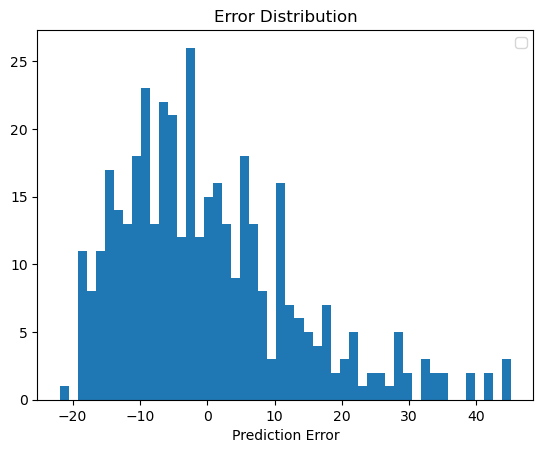

In [515]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [516]:
zipped = zip(attributes, dt_reg_SDS_Total.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Height 0.4616284276762882
BIA-BIA_FFMI 0.38076547962672297
BIA-BIA_FMI 0.1576060926969888
Basic_Demos-Age 0.0
Basic_Demos-Sex 0.0
Physical-Weight 0.0


## ** TARGET VARIABLE PreInt_EduHx-computerinternet_hoursday'

In [517]:
df_computerinternet= df[[
'Basic_Demos-Age', 'CGAS-CGAS_Score', 
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'FGC-FGC_TL',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW',
       'PreInt_EduHx-computerinternet_hoursday'
]]



In [518]:
df_computerinternet=df_computerinternet.dropna()

In [519]:
df_computerinternet.isnull().sum()

Basic_Demos-Age                           0
CGAS-CGAS_Score                           0
Physical-Height                           0
Physical-Weight                           0
BIA-BIA_BMR                               0
Physical-HeartRate                        0
FGC-FGC_TL                                0
BIA-BIA_Frame_num                         0
BIA-BIA_SMM                               0
BIA-BIA_TBW                               0
PreInt_EduHx-computerinternet_hoursday    0
dtype: int64

### Partitioning

In [520]:
attributes = [col for col in df_computerinternet.columns if col != 'PreInt_EduHx-computerinternet_hoursday']
X = df_computerinternet[attributes].values
y = np.array(df_computerinternet['PreInt_EduHx-computerinternet_hoursday'])

In [521]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [522]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1138, 10) (380, 10) (1138,) (380,)


In [523]:
df_computerinternet.shape

(1518, 11)

### Randomized Search

In [524]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [525]:
# param_list = {
#     'max_depth': [None] + list(np.arange(10, 50)),
#     'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
#     'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
#     'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
# }

# dt_reg_computerinternet = DecisionTreeRegressor()  

# random_search = RandomizedSearchCV(
#     DecisionTreeRegressor(),    
#     param_distributions=param_list,
#     cv=KFold(n_splits=5, shuffle=True, random_state=0), 
#     scoring='neg_mean_squared_error' ,   
#     n_jobs=-1,
#     refit=True,
#     n_iter=300,
# )

# random_search.fit(X_train, y_train)
# dt_reg_computerinternet = random_search.best_estimator_

In [526]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 150, 'max_depth': 27, 'criterion': 'friedman_mse'} -178.70670499660747


In [527]:
dt_reg_computerinternet = random_search.best_estimator_
dt_reg_computerinternet.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=27,
                      min_samples_leaf=150, min_samples_split=0.002)

In [528]:
y_pred = dt_reg_computerinternet.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 0.9412
MAE  : 0.8117
MSE  : 0.8859
R²   : 0.1583


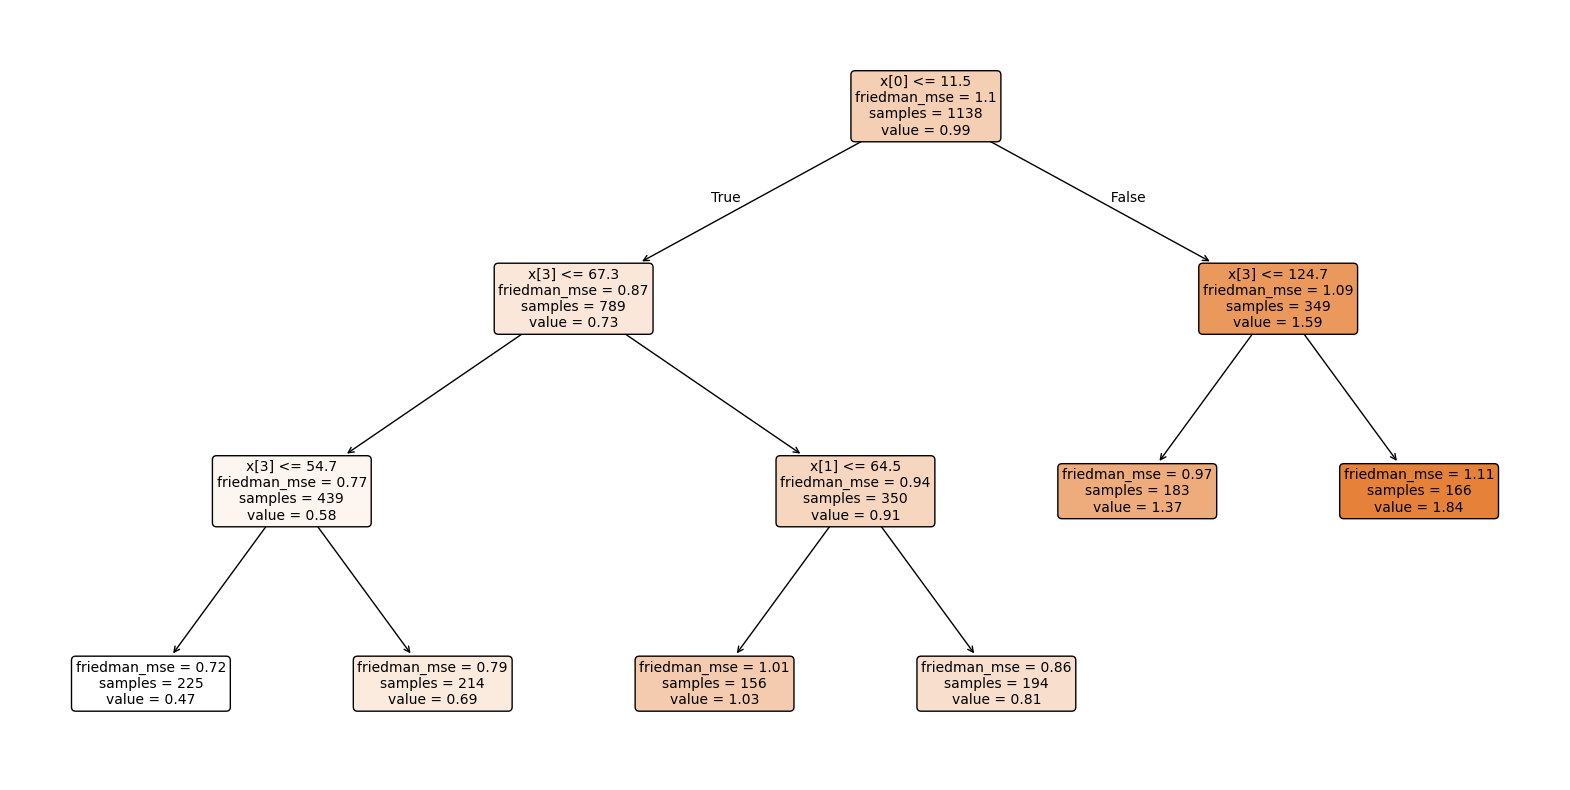

In [529]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_computerinternet,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 4
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 291 |  3.0000 |    0.6916 | 2.3084
  29 |  3.0000 |    0.6916 | 2.3084
  31 |  3.0000 |    0.8144 | 2.1856
 134 |  3.0000 |    0.8144 | 2.1856
 190 |  3.0000 |    0.8144 | 2.1856
 122 |  3.0000 |    1.0321 | 1.9679
 315 |  3.0000 |    1.0321 | 1.9679
  39 |  3.0000 |    1.0321 | 1.9679
 345 |  3.0000 |    1.0321 | 1.9679
 188 |  0.0000 |    1.8373 | 1.8373


C:\Users\paula\AppData\Local\Temp\ipykernel_26128\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


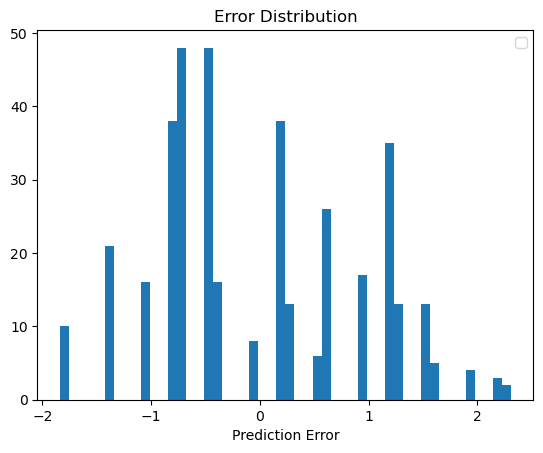

In [530]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [531]:
zipped = zip(attributes, dt_reg_computerinternet.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.784727451600078
Physical-Weight 0.19760068652452992
CGAS-CGAS_Score 0.017671861875392197
Physical-Height 0.0
BIA-BIA_BMR 0.0
Physical-HeartRate 0.0
FGC-FGC_TL 0.0
BIA-BIA_Frame_num 0.0
BIA-BIA_SMM 0.0
BIA-BIA_TBW 0.0


# IMPORT TOTAL DATASET

In [532]:
file_path = "../1.DATASET/CMI_V2.csv"
df_notna=pd.read_csv(file_path)
df_notna

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.00,50.8,932.498000,NaN,5.0,...,1.0,19.541300,32.690900,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.500000
1,1,9,0,NaN,14.035590,48.00,46.0,936.656000,70.0,NaN,...,1.0,15.410700,27.055200,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
2,2,10,1,71.0,16.648696,56.50,75.6,1115.380000,94.0,5.0,...,NaN,NaN,44.987000,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.000000
3,3,9,0,71.0,18.292347,56.00,81.6,1131.430000,97.0,6.0,...,2.0,26.479800,45.996600,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
4,4,18,1,65.0,17.937682,NaN,77.0,1578.400000,NaN,NaN,...,2.0,NaN,NaN,NaN,1.0,0.0,90.152104,12.000000,26.463732,8.003205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,7,1,NaN,16.130585,46.07,49.0,979.009933,82.5,2.5,...,1.0,NaN,31.583004,55.0,0.0,0.0,81.861037,6.500000,18.075000,7.000000
8456,8456,10,1,69.5,17.300000,56.13,47.8,1029.411546,80.5,5.0,...,1.0,22.983200,36.475662,NaN,0.0,1.0,79.833333,8.500000,13.575000,5.000000
8457,8457,10,1,70.0,40.937571,49.56,47.2,1034.387599,83.5,7.0,...,2.0,31.594712,35.106855,NaN,2.0,0.0,82.166667,21.500000,16.840263,9.500000
8458,8458,15,1,55.5,22.500000,63.79,99.5,1379.703447,87.5,NaN,...,2.0,46.467581,57.530686,NaN,1.0,2.0,88.395702,10.000000,26.417470,10.500000


In [533]:
df_notna.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Age                         8460 non-null   int64  
 2   Basic_Demos-Sex                         8460 non-null   int64  
 3   CGAS-CGAS_Score                         7034 non-null   float64
 4   Physical-BMI                            8460 non-null   float64
 5   Physical-Height                         7595 non-null   float64
 6   Physical-Weight                         7641 non-null   float64
 7   BIA-BIA_BMR                             8460 non-null   float64
 8   Physical-HeartRate                      7539 non-null   float64
 9   Fitness_Endurance-Max_Stage             5480 non-null   float64
 10  FGC-FGC_TL                              6945 non-null   floa

In [534]:
df_notna['BIA-BIA_BMR'].value_counts()

BIA-BIA_BMR
1115.380000    985
1044.200000    145
1080.800000    140
878.800000     121
990.600000     120
              ... 
1311.730000      1
1615.670000      1
923.038000       1
978.827000       1
1015.199123      1
Name: count, Length: 5627, dtype: int64

In [535]:
df_notna['BIA-BIA_TBW'][df_notna['BIA-BIA_BMR']==1115.38].value_counts()

BIA-BIA_TBW
44.987    497
45.886      1
Name: count, dtype: int64

# REPLACE NULL VALUES

## 'Physical-Height'

In [536]:
attributes = ['id','Physical-BMI','Physical-Height', 'Physical-Weight']
df_unknown=df_notna[attributes][(df_notna['Physical-Height'].isna()) | (df_notna['Physical-Height']==0)].copy()
df_unknown.isnull().sum()

id                   0
Physical-BMI         0
Physical-Height    865
Physical-Weight    260
dtype: int64

In [537]:
attributes = [col for col in df_unknown.columns if col not in ['Physical-Height','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_height.predict(X_unknown)

In [538]:
df_unknown['Physical-Height_DT'] = predicted_value
df_unknown=df_unknown[['id','Physical-Height_DT']]
df_unknown

,id,Physical-Height_DT
4,4,55.065
26,26,59.875
30,30,54.000
35,35,51.000
42,42,55.065
...,...,...
8408,8408,63.000
8435,8435,63.000
8437,8437,70.000
8447,8447,59.500


In [539]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['Physical-Height'].isnull()) | (df_notna['Physical-Height']==0)) , 'Physical-Height'] = df_notna['Physical-Height_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                            819
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                               1824
BIA-BIA_LST  

In [540]:
list1 = [44]

df_notna[df_notna.id.isin(list1) == True]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-Height_DT
44,44,7,1,66.0,17.937682,42.0,0.0,1115.38,81.0,NaN,...,27.4151,NaN,47.0,0.0,0.0,83.333333,9.540221,20.625,8.749076,42.0


## 'Physical-Weight'

In [541]:
df_notna['Physical-Weight'] = (df_notna['Physical-BMI']/703)*(df_notna['Physical-Height']*df_notna['Physical-Height'])

In [542]:
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                               1824
BIA-BIA_LST  

In [543]:
df_notna[df_notna['Physical-Weight']==0]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-Height_DT


In [544]:
list1 = [4009, 4759,4837,4957,5518,5761,5780,5861,6844]
df_notna[df_notna.id.isin(list1) == True]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-Height_DT
4009,4009,12,0,60.5,23.980762,63.66,138.242292,1245.735561,115.0,NaN,...,40.854724,NaN,NaN,1.0,0.0,80.333333,19.750620,20.626092,5.500000,NaN
4759,4759,15,0,NaN,17.553132,70.90,125.513886,1575.877057,80.0,5.0,...,21.858223,68.160583,NaN,2.0,0.0,75.166667,23.714789,26.417470,6.000000,NaN
4837,4837,9,1,NaN,20.281036,57.88,96.647773,1077.297940,85.0,6.0,...,NaN,40.805493,45.0,1.0,0.0,80.500000,5.000000,18.075000,9.000000,NaN
4957,4957,8,1,60.0,18.089762,51.08,67.139687,1066.616623,86.0,NaN,...,19.882174,36.493332,NaN,1.0,0.0,82.926177,10.568299,18.526452,5.500000,NaN
5518,5518,15,1,61.5,25.254572,49.14,86.747104,1357.598793,66.5,NaN,...,61.218195,61.906035,49.5,2.0,0.0,97.166667,23.714789,16.500000,8.527654,NaN
5761,5761,8,0,NaN,17.400000,57.42,81.605663,1044.200000,75.5,5.5,...,22.766050,34.336378,NaN,0.0,2.0,79.666667,5.000000,18.526452,7.500000,NaN
5780,5780,9,1,62.0,21.485738,56.62,97.979379,1338.784991,75.5,4.5,...,41.133904,34.655397,NaN,0.0,0.0,84.166427,12.787145,18.204545,4.000000,NaN
5861,5861,8,1,71.0,17.484574,57.86,83.263871,1055.929249,86.5,4.0,...,29.481443,NaN,56.0,0.0,0.0,78.833333,10.500000,18.526452,8.667797,NaN
6844,6844,10,0,62.5,17.480237,69.19,119.036090,1080.800000,82.0,4.0,...,30.658356,NaN,NaN,0.0,0.0,83.166667,26.500000,29.900000,7.682875,NaN


## Physical-BMI

In [545]:
df_notna['Physical-BMI']=(df_notna['Physical-Weight']/(df_notna['Physical-Height']*df_notna['Physical-Height']))*703 

In [546]:
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                               1824
BIA-BIA_LST  

In [547]:
df_notna[['Physical-Height','Physical-Weight','Physical-BMI']][df_notna['Physical-BMI']==0]

,Physical-Height,Physical-Weight,Physical-BMI


In [548]:
list1 = [4009, 4759,4837,4957,5518,5761,5780,5861,6844]
df_notna[df_notna.id.isin(list1) == True]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-Height_DT
4009,4009,12,0,60.5,23.980762,63.66,138.242292,1245.735561,115.0,NaN,...,40.854724,NaN,NaN,1.0,0.0,80.333333,19.750620,20.626092,5.500000,NaN
4759,4759,15,0,NaN,17.553132,70.90,125.513886,1575.877057,80.0,5.0,...,21.858223,68.160583,NaN,2.0,0.0,75.166667,23.714789,26.417470,6.000000,NaN
4837,4837,9,1,NaN,20.281036,57.88,96.647773,1077.297940,85.0,6.0,...,NaN,40.805493,45.0,1.0,0.0,80.500000,5.000000,18.075000,9.000000,NaN
4957,4957,8,1,60.0,18.089762,51.08,67.139687,1066.616623,86.0,NaN,...,19.882174,36.493332,NaN,1.0,0.0,82.926177,10.568299,18.526452,5.500000,NaN
5518,5518,15,1,61.5,25.254572,49.14,86.747104,1357.598793,66.5,NaN,...,61.218195,61.906035,49.5,2.0,0.0,97.166667,23.714789,16.500000,8.527654,NaN
5761,5761,8,0,NaN,17.400000,57.42,81.605663,1044.200000,75.5,5.5,...,22.766050,34.336378,NaN,0.0,2.0,79.666667,5.000000,18.526452,7.500000,NaN
5780,5780,9,1,62.0,21.485738,56.62,97.979379,1338.784991,75.5,4.5,...,41.133904,34.655397,NaN,0.0,0.0,84.166427,12.787145,18.204545,4.000000,NaN
5861,5861,8,1,71.0,17.484574,57.86,83.263871,1055.929249,86.5,4.0,...,29.481443,NaN,56.0,0.0,0.0,78.833333,10.500000,18.526452,8.667797,NaN
6844,6844,10,0,62.5,17.480237,69.19,119.036090,1080.800000,82.0,4.0,...,30.658356,NaN,NaN,0.0,0.0,83.166667,26.500000,29.900000,7.682875,NaN


## 'BIA-BIA-TBW'

In [549]:
attributes = ['id','BIA-BIA_TBW','BIA-BIA_ECW', 'BIA-BIA_ICW']
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_TBW']==0) |(df_notna['BIA-BIA_TBW'].isna()) | (df_notna['BIA-BIA_TBW']==44.987)| (df_notna['BIA-BIA_TBW']>=df_notna['Physical-Weight'])].copy()
df_unknown.isnull().sum()

id                0
BIA-BIA_TBW    1824
BIA-BIA_ECW       1
BIA-BIA_ICW       0
dtype: int64

In [550]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_TBW','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_height.predict(X_unknown)

In [551]:
X_unknown.shape

(2880, 2)

In [552]:
df_unknown['BIA-BIA_TBW_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_TBW_DT']]
df_unknown

,id,BIA-BIA_TBW_DT
2,2,42.000
4,4,42.000
8,8,46.000
9,9,42.000
10,10,42.000
...,...,...
8405,8405,42.000
8413,8413,42.625
8424,8424,42.000
8437,8437,45.000


In [553]:
df_notna[df_notna['id']==71]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-Height_DT
71,71,5,1,NaN,13.943802,44.0,38.4,1115.38,99.0,5.0,...,NaN,44.987,NaN,0.0,0.0,74.666667,4.611111,17.883041,8.897552,NaN


In [554]:
df_unknown[df_unknown['id']==71]

,id,BIA-BIA_TBW_DT
71,71,42.0


In [555]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_TBW']==0) |(df_notna['BIA-BIA_TBW'].isna()) | (df_notna['BIA-BIA_TBW']==44.987)| (df_notna['BIA-BIA_TBW']>=df_notna['Physical-Weight'])) , 'BIA-BIA_TBW'] = df_notna['BIA-BIA_TBW_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                               1824
BIA-BIA_LST  

In [556]:
df_notna[df_notna['BIA-BIA_TBW']>=df_notna['Physical-Weight']]

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,Physical-Height_DT,BIA-BIA_TBW_DT
71,71,5,1,NaN,13.943802,44.000,38.400000,1115.380000,99.0,5.0,...,42.000,NaN,0.0,0.0,74.666667,4.611111,17.883041,8.897552,NaN,42.000
166,166,7,0,35.0,15.900000,42.000,39.897013,1115.380000,NaN,NaN,...,42.625,75.0,NaN,0.0,81.861037,12.000000,20.625000,9.000000,42.000,42.625
217,217,6,0,61.0,15.400000,42.000,38.642390,1115.380000,NaN,NaN,...,42.000,45.0,0.0,0.0,83.333333,12.000000,18.613018,8.886824,42.000,42.000
256,256,6,0,65.0,15.400000,42.000,38.642390,878.800000,81.0,5.0,...,42.000,63.0,1.0,1.0,83.333333,6.280570,20.625000,9.000000,42.000,42.000
263,263,7,1,65.0,16.100000,42.000,40.398862,1115.380000,81.0,5.0,...,42.625,55.0,0.0,0.0,83.333333,9.540221,20.625000,8.749076,42.000,42.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4274,4274,11,1,71.0,16.800000,42.000,42.155334,1413.383748,77.5,4.5,...,42.625,NaN,2.0,2.0,85.695946,19.000000,18.544625,4.000000,42.000,42.625
7129,7129,5,0,60.5,13.700300,42.625,35.408175,926.745840,68.5,4.0,...,42.625,45.5,0.0,0.0,82.152821,4.611111,16.800000,8.500000,42.625,42.625
7371,7371,7,1,86.5,16.529744,42.000,41.477196,886.769743,71.0,5.5,...,42.625,NaN,0.0,0.0,70.166667,9.000000,18.909726,11.500000,42.000,42.625
7699,7699,7,0,54.5,15.932547,42.500,40.936221,902.592013,83.0,6.0,...,42.625,NaN,0.0,0.0,98.833333,3.500000,18.075000,7.000000,42.500,42.625


## 'BIA-BIA_Fat'

In [557]:
attributes = ['id','Physical-Weight', 
                'Physical-Height','BIA-BIA_FMI',
                'BIA-BIA_Fat' ]
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_Fat']<=0) |(df_notna['BIA-BIA_Fat'].isna()) | (df_notna['BIA-BIA_Fat']==16.1746)| (df_notna['BIA-BIA_Fat']>=df_notna['Physical-Weight'])].copy()
df_unknown.isnull().sum()

id                    0
Physical-Weight       0
Physical-Height       0
BIA-BIA_FMI           0
BIA-BIA_Fat        1824
dtype: int64

In [558]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_Fat','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_FAT.predict(X_unknown)

In [559]:
X_unknown.shape

(2951, 3)

In [560]:
df_unknown['BIA-BIA_Fat_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_Fat_DT']]
df_unknown

,id,BIA-BIA_Fat_DT
2,2,15.811750
4,4,15.811750
8,8,17.948622
9,9,17.948622
10,10,18.959044
...,...,...
8436,8436,9.153611
8450,8450,6.346703
8451,8451,54.885367
8457,8457,35.051020


In [561]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_Fat']<=0) |(df_notna['BIA-BIA_Fat'].isna()) | (df_notna['BIA-BIA_Fat']==16.1746)| (df_notna['BIA-BIA_Fat']>=df_notna['Physical-Weight'])), 'BIA-BIA_Fat'] = df_notna['BIA-BIA_Fat_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST  

## 'BIA-BIA_Activity_Level_num'

In [562]:
attributes = ['id','BIA-BIA_DEE',
'BIA-BIA_FFM',
'BIA-BIA_LST',
'Physical-Weight',
'BIA-BIA_ICW',
'BIA-BIA_TBW',
'BIA-BIA_Activity_Level_num']
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_Activity_Level_num']==0) |(df_notna['BIA-BIA_Activity_Level_num'].isna())].copy()
df_unknown.isnull().sum()

id                               0
BIA-BIA_DEE                    681
BIA-BIA_FFM                      1
BIA-BIA_LST                      1
Physical-Weight                  0
BIA-BIA_ICW                      0
BIA-BIA_TBW                      0
BIA-BIA_Activity_Level_num    1824
dtype: int64

In [563]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_Activity_Level_num','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_CL_ACT_LEV.predict(X_unknown)

In [564]:
X_unknown.shape

(1824, 6)

In [565]:
df_unknown['BIA-BIA_Activity_Level_num_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_Activity_Level_num_DT']]
df_unknown

,id,BIA-BIA_Activity_Level_num_DT
2,2,3.0
4,4,3.0
8,8,2.0
9,9,3.0
10,10,3.0
...,...,...
8431,8431,2.0
8434,8434,2.0
8436,8436,2.0
8437,8437,2.0


In [566]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_Activity_Level_num']==0) |(df_notna['BIA-BIA_Activity_Level_num'].isna()) ), 'BIA-BIA_Activity_Level_num'] = df_notna['BIA-BIA_Activity_Level_num_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                   0
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST  

## BIA-BIA_DEE'

In [567]:
attributes = ['id','BIA-BIA_DEE',
    'BIA-BIA_BMR',                  
    'BIA-BIA_Activity_Level_num',   
    'Basic_Demos-Sex',
    'BIA-BIA_TBW'  ]
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_DEE']==0) |(df_notna['BIA-BIA_DEE'].isna()) | (df_notna['BIA-BIA_DEE']==1863.98)| (df_notna['BIA-BIA_DEE']>10000)].copy()
df_unknown.isnull().sum()

id                               0
BIA-BIA_DEE                   1824
BIA-BIA_BMR                      0
BIA-BIA_Activity_Level_num       0
Basic_Demos-Sex                  0
BIA-BIA_TBW                      0
dtype: int64

In [568]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_DEE','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_DEE.predict(X_unknown)

In [569]:
X_unknown.shape

(2821, 4)

In [570]:
df_unknown['BIA-BIA_DEE_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_DEE_DT']]
df_unknown

,id,BIA-BIA_DEE_DT
2,2,1796.890
4,4,2652.510
8,8,1784.460
9,9,2080.475
10,10,2080.475
...,...,...
8415,8415,1744.310
8416,8416,1713.710
8417,8417,2281.290
8434,8434,2401.570


In [571]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_DEE']==0) |(df_notna['BIA-BIA_DEE'].isna()) | (df_notna['BIA-BIA_DEE']==1863.98)| (df_notna['BIA-BIA_DEE']>10000)), 'BIA-BIA_DEE'] = df_notna['BIA-BIA_DEE_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                   0
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                                  0
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST  

## 'BIA-BIA_BMC'

In [572]:
attributes = ['id','BIA-BIA_LST' ,
'BIA-BIA_ICW',
'BIA-BIA_BMR' ,
'BIA-BIA_BMC']
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_BMC']<=0) |(df_notna['BIA-BIA_BMC'].isna()) | (df_notna['BIA-BIA_BMC']==3.92272)| (df_notna['BIA-BIA_BMC']>50)].copy()
df_unknown.isnull().sum()

id                0
BIA-BIA_LST       1
BIA-BIA_ICW       0
BIA-BIA_BMR       0
BIA-BIA_BMC    1824
dtype: int64

In [573]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_BMC','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_BMC.predict(X_unknown)

In [574]:
X_unknown.shape

(2867, 3)

In [575]:
df_unknown['BIA-BIA_BMC_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_BMC_DT']]
df_unknown

,id,BIA-BIA_BMC_DT
2,2,3.389932
4,4,12.054014
8,8,3.849484
9,9,12.054014
10,10,5.569922
...,...,...
8449,8449,2.796458
8450,8450,2.221104
8452,8452,2.584290
8458,8458,4.967841


In [576]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_BMC']<=0) |(df_notna['BIA-BIA_BMC'].isna()) | (df_notna['BIA-BIA_BMC']==3.92272) | (df_notna['BIA-BIA_BMC']>50)), 'BIA-BIA_BMC'] = df_notna['BIA-BIA_BMC_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                   0
BIA-BIA_BMI                               1824
BIA-BIA_BMC                                  0
BIA-BIA_DEE                                  0
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST  

## 'BIA-BIA_SMM'

In [577]:
attributes = ['id','BIA-BIA_LST',
'BIA-BIA_ICW',
'BIA-BIA_FFM',
'BIA-BIA_SMM' ]
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_SMM']==0) |(df_notna['BIA-BIA_SMM'].isna()) | (df_notna['BIA-BIA_SMM']==27.4151)| (df_notna['BIA-BIA_SMM']>=df_notna['BIA-BIA_FFM'])| (df_notna['BIA-BIA_SMM']>=df_notna['Physical-Weight'])].copy()
df_unknown.isnull().sum()

id                0
BIA-BIA_LST       1
BIA-BIA_ICW       0
BIA-BIA_FFM       1
BIA-BIA_SMM    1824
dtype: int64

In [578]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_SMM','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_SMM.predict(X_unknown)

In [579]:
X_unknown.shape

(2912, 3)

In [580]:
df_unknown['BIA-BIA_SMM_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_SMM_DT']]
df_unknown

,id,BIA-BIA_SMM_DT
2,2,23.89330
4,4,29.94595
8,8,39.74630
9,9,29.94595
10,10,26.36160
...,...,...
8430,8430,29.94595
8436,8436,20.64315
8448,8448,20.64315
8450,8450,15.72140


In [581]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_SMM']==0) |(df_notna['BIA-BIA_SMM'].isna()) | (df_notna['BIA-BIA_SMM']==27.4151)| (df_notna['BIA-BIA_SMM']>=df_notna['BIA-BIA_FFM'])| (df_notna['BIA-BIA_SMM']>=df_notna['Physical-Weight'])), 'BIA-BIA_SMM'] = df_notna['BIA-BIA_SMM_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                   0
BIA-BIA_BMI                               1824
BIA-BIA_BMC                                  0
BIA-BIA_DEE                                  0
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST  

## 'BIA-BIA_Frame_num'

In [582]:
attributes = ['id','Physical-Height', 
       'Physical-Weight',
       'BIA-BIA_Fat' ,
       'BIA-BIA_Frame_num']
df_unknown=df_notna[attributes][(df_notna['BIA-BIA_Frame_num']==0) |(df_notna['BIA-BIA_Frame_num'].isna()) ].copy()
df_unknown.isnull().sum()

id                      0
Physical-Height         0
Physical-Weight         0
BIA-BIA_Fat             0
BIA-BIA_Frame_num    1824
dtype: int64

In [583]:
attributes = [col for col in df_unknown.columns if col not in ['BIA-BIA_Frame_num','id']]
X_unknown = df_unknown[attributes].fillna(0).values
predicted_value = dt_reg_Frame.predict(X_unknown)

In [584]:
X_unknown.shape

(1824, 3)

In [585]:
df_unknown['BIA-BIA_Frame_num_DT'] = predicted_value
df_unknown=df_unknown[['id','BIA-BIA_Frame_num_DT']]
df_unknown

,id,BIA-BIA_Frame_num_DT
2,2,2.0
8,8,2.0
11,11,2.0
13,13,2.0
21,21,2.0
...,...,...
8440,8440,2.0
8442,8442,2.0
8450,8450,1.0
8452,8452,2.0


In [586]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['BIA-BIA_Frame_num']==0) |(df_notna['BIA-BIA_Frame_num'].isna())), 'BIA-BIA_Frame_num'] = df_notna['BIA-BIA_Frame_num_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                   0
BIA-BIA_BMI                               1824
BIA-BIA_BMC                                  0
BIA-BIA_DEE                                  0
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST  

# not null dataset 

In [587]:
df_notna.shape

(8460, 40)

In [588]:
df_notna.columns


Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC',
       'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFMI',
       'BIA-BIA_FFM', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_LST',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL',
       'Physical-Height_DT', 'BIA-BIA_TBW_DT', 'BIA-BIA_Fat_DT',
       'BIA-BIA_Activity_Level_num_DT', 'BIA-BIA_DEE_DT', 'BIA-BIA_BMC_DT',
       'BIA-BIA_SMM_DT', 'BIA-BIA_Frame_num_DT'],
      dtype='object')

In [589]:
df_notna=df_notna.drop(columns = 
  [
    'Physical-Height_DT', 'BIA-BIA_TBW_DT', 'BIA-BIA_Fat_DT',
    'BIA-BIA_Activity_Level_num_DT', 'BIA-BIA_DEE_DT', 'BIA-BIA_BMC_DT',
    'BIA-BIA_SMM_DT', 'BIA-BIA_Frame_num_DT',   
'BIA-BIA_FFMI',
'BIA-BIA_BMI'
  ])

In [590]:
df_notna.columns

Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [591]:
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
BIA-BIA_BMR                                  0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                   0
BIA-BIA_BMC                                  0
BIA-BIA_DEE                                  0
BIA-BIA_ECW                                  1
BIA-BIA_ICW                                  0
BIA-BIA_FFM                                  1
BIA-BIA_FMI                                  0
BIA-BIA_Fat                                  0
BIA-BIA_LST                                  1
BIA-BIA_Frame_num                            0
BIA-BIA_SMM  

In [592]:
df_notna.to_csv('../1.DATASET/CMI_NN_V2.csv', index=False)